# Bivariate Exploratory Data Analysis — `epa-full.csv`

**Input:** `data/final/epa-full.csv` — the terminal (T1) modeling table from the
merge pipeline (`MERGE.md`). One row per water-quality observation
(`MonitoringLocationIdentifier` × `ActivityStartDateTime`), joined to climate, weather,
streamflow, soil, land-cover and agricultural-context attributes.

**Scope:** *two variables at a time.* The companion notebooks bracket this one.
[`univariate-analysis.ipynb`](univariate-analysis.ipynb) established what each variable is on
its own — units, distribution, missingness, censoring.
[`multivariate-analysis.ipynb`](multivariate-analysis.ipynb) established how the 30-column
input space is structured as a whole — clusters, VIF, PCA, the between/within-station split.

This notebook works at the level those two skip: **the individual pair.** A correlation
coefficient is a one-number summary of a two-dimensional object, and it discards almost
everything about it. Here each pair is asked five questions the coefficient cannot answer:

1. **What shape is it?** — monotone, humped, threshold, or nothing at all
2. **How big is it in the units the variable is actually measured in?** — °C per °C, mg/L per hectare
3. **How much of it is one observation?** — leave-one-out influence
4. **How certain is it?** — standard errors that respect the fact that rows repeat at stations
5. **Does it survive when one of the two variables isn't a number?** — group differences and
   contingency, which no correlation matrix contains

Pairs where one member is a **category**, where one member is **presence versus absence**, and
where the pair is *the same variable at two different times or two different places* are all
bivariate relationships too, and none of them appear in a Spearman matrix.

**What this notebook covers**

| § | Section |
|---|---------|
| 0 | Setup, plot style, variable contract |
| 1 | Anatomy of a pair — what a coefficient throws away |
| 2 | Numeric ↔ numeric: joint density, shape census, effect size, spread |
| 3 | How much can one pairwise number be trusted? — clustering, multiplicity, influence |
| 4 | Numeric ↔ categorical: group differences and their effect size |
| 5 | Categorical ↔ categorical: how the design variables are entangled |
| 6 | Presence ↔ value: is missingness informative? |
| 7 | A variable and its own past — temporal autocorrelation |
| 8 | A variable and its neighbour — spatial autocorrelation |
| 9 | Findings |
| 10 | Red flags |

Summary tables are written to `src/04_eda/outputs/` with a `bv_` prefix.

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import FuncFormatter
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

# Locate the repo root from wherever the kernel was started.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "final").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "final" / "epa-full.csv"
METRICS_PATH = REPO_ROOT / "src" / "05_modeling" / "model_metrics.csv"
OUT_DIR = REPO_ROOT / "src" / "04_eda" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data file :", DATA_PATH.relative_to(REPO_ROOT), f"({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print("outputs   :", OUT_DIR.relative_to(REPO_ROOT))

repo root : /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN Fellowship Project 2026/workspace/Water-Quality-Prediction
data file : data/final/epa-full.csv (81.0 MB)
outputs   : src/04_eda/outputs


### Plot style

The same recessive style as the other two notebooks: one hue for magnitude, a diverging blue–
gray–red ramp for anything signed, thin marks, a muted grid behind the data. Two forms are
used here that the earlier notebooks did not need — **hexbin**, because 34,000 overplotted
points are a silhouette rather than a distribution, and **binned conditional quantiles**,
which is the honest way to draw a relationship when the response is heavily skewed.

In [2]:
SURFACE   = "#ffffff"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRIDLINE  = "#dcdbd6"
AXISLINE  = "#b8b7b2"

# Fixed categorical order (validated for CVD separation); slot 1 doubles as the
# single hue used for every magnitude chart.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, RED = SERIES[0], SERIES[1], SERIES[2], SERIES[7]

DIVERGING = LinearSegmentedColormap.from_list("wq_div", [
    "#0d366b", "#1c5cab", "#2a78d6", "#86b6ef", "#cde2fb",
    "#f0efec",
    "#fbd2d1", "#f19392", "#e34948", "#b32f2e", "#7a1c1b",
]).copy()
DIVERGING.set_bad(SURFACE)

SEQUENTIAL = LinearSegmentedColormap.from_list("wq_seq", [
    "#eef5fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b",
]).copy()
SEQUENTIAL.set_bad(SURFACE)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXISLINE,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "medium",
    "axes.labelsize": 8.5,
    "text.color": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})


def style_axes(ax, axis="y"):
    """Recessive grid + two spines. Grid sits behind the marks."""
    ax.grid(axis=axis, color=GRIDLINE, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(length=0)
    return ax


def thousands(ax, axis="y"):
    fmt = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax


def heatmap(mat, ax, cmap=DIVERGING, vmin=-1, vmax=1, annot_at=0.60, fmt="{:+.2f}",
            fontsize=6.8, mask_diagonal=False, light_text_above=0.72):
    """Matrix heatmap with a 1px surface gap between cells and selective direct labels."""
    data = mat.to_numpy(dtype=float).copy()
    if mask_diagonal:
        np.fill_diagonal(data, np.nan)
    im = ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=fontsize)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=fontsize)
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=1.0)
    ax.tick_params(which="both", length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    if annot_at is not None:
        span = max(abs(vmin), abs(vmax))
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = data[i, j]
                if np.isfinite(v) and abs(v) >= annot_at:
                    ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=fontsize - 0.6,
                            color="#ffffff" if abs(v) / span > light_text_above else INK)
    return im


def add_colorbar(fig, im, ax, label, ticks=None):
    cb = fig.colorbar(im, ax=ax, fraction=0.026, pad=0.02, ticks=ticks)
    cb.set_label(label, fontsize=8, color=INK_SOFT)
    cb.outline.set_visible(False)
    cb.ax.tick_params(labelsize=7.5, length=0, color=INK_SOFT)
    return cb

### Load and rebuild the modeling contract

In [3]:
DATE_COL = "ActivityStartDateTime"
ID_COL = "MonitoringLocationIdentifier"

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL], low_memory=False)

# The 4 temporal features app.py derives at inference time, plus two calendar helpers.
df["doy"] = df[DATE_COL].dt.dayofyear
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365.25)
df["obs_year"] = df[DATE_COL].dt.year
df["obs_month"] = df[DATE_COL].dt.month
df["season"] = pd.Categorical(
    df["obs_month"].map({12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
                         5: "Spring", 6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall",
                         10: "Fall", 11: "Fall"}),
    categories=["Winter", "Spring", "Summer", "Fall"], ordered=True)

print(f"rows {df.shape[0]:,} x columns {df.shape[1]:,}")
print(f"stations {df[ID_COL].nunique():,}   "
      f"span {df[DATE_COL].min():%Y-%m-%d} -> {df[DATE_COL].max():%Y-%m-%d}")

rows 48,251 x columns 321
stations 1,345   span 2015-01-02 -> 2025-12-25


In [4]:
# Mirrored from app.py so this EDA looks at exactly the columns the models consume.
# Keep in sync with app.py::TARGET_COLS / FEATURE_COLS.
TARGET_COLS = {
    "Water Temperature":      "Temperature, water_value",
    "Dissolved Oxygen":       "Dissolved oxygen (DO)_value",
    "pH":                     "pH_value",
    "Nitrate":                "Nitrate_value",
    "Nitrite":                "Nitrite_value",
    "Nitrate + Nitrite":      "Nitrate + Nitrite_value",
    "Total Phosphorus":       "Total Phosphorus, mixed forms_value",
    "Specific Conductance":   "Specific conductance_value",
    "Total Dissolved Solids": "Total dissolved solids_value",
    "Total Suspended Solids": "Total suspended solids_value",
    "Turbidity":              "Turbidity_value",
    "E. coli":                "Escherichia coli_value",
}

BASE_FEATURE_COLS = [
    "LatitudeMeasure", "LongitudeMeasure",
    "distance_to_climate_station_km", "distance_to_streamflow_gauge_km",
    "prism_tmax_c", "prism_tmin_c", "prism_ppt_mm", "prism_tdmean_c",
    "isu_avg_wind_speed_kts", "isu_avg_rh", "isu_snow_in", "isu_snowd_in",
    "isu_max_feel_c", "isu_min_feel_c",
    "streamflow_discharge_cfs",
    "ksat_mean", "awc_mean",
    "pct_corn", "pct_soybean", "pct_developed", "pct_forest", "pct_row_crops",
    "npfert__n__total_kg", "npfert__p__total_kg",
    "npmanure__total__n_kg", "npmanure__total__p_kg",
]
TEMPORAL_FEATURE_COLS = ["doy", "doy_sin", "doy_cos", "obs_year"]
FEATURE_COLS = BASE_FEATURE_COLS + TEMPORAL_FEATURE_COLS
assert len(FEATURE_COLS) == 30, len(FEATURE_COLS)

# Source block per feature, as in the multivariate notebook.
FEATURE_BLOCK = {
    **{c: "location"   for c in ["LatitudeMeasure", "LongitudeMeasure",
                                 "distance_to_climate_station_km",
                                 "distance_to_streamflow_gauge_km"]},
    **{c: "climate"    for c in ["prism_tmax_c", "prism_tmin_c", "prism_ppt_mm", "prism_tdmean_c"]},
    **{c: "weather"    for c in ["isu_avg_wind_speed_kts", "isu_avg_rh", "isu_snow_in",
                                 "isu_snowd_in", "isu_max_feel_c", "isu_min_feel_c"]},
    "streamflow_discharge_cfs": "streamflow",
    **{c: "soil"       for c in ["ksat_mean", "awc_mean"]},
    **{c: "land cover" for c in ["pct_corn", "pct_soybean", "pct_developed",
                                 "pct_forest", "pct_row_crops"]},
    **{c: "nutrients"  for c in ["npfert__n__total_kg", "npfert__p__total_kg",
                                 "npmanure__total__n_kg", "npmanure__total__p_kg"]},
    **{c: "temporal"   for c in TEMPORAL_FEATURE_COLS},
}
BLOCK_ORDER = ["location", "climate", "weather", "streamflow", "soil",
               "land cover", "nutrients", "temporal"]
BLOCK_COLOR = dict(zip(BLOCK_ORDER, SERIES))

TARGET_VALUE_COLS = list(TARGET_COLS.values())
COL_TO_LABEL = {v: k for k, v in TARGET_COLS.items()}
TARGET_UNIT = {label: (df.loc[df[col].notna(), col.replace("_value", "_unit")].dropna().iloc[0]
                       if df[col].notna().any() else "")
               for label, col in TARGET_COLS.items()}

missing = [c for c in FEATURE_COLS + TARGET_VALUE_COLS if c not in df.columns]
print("contract columns missing from the table:", missing or "none")

# Numeric analysis frame: 12 targets + 30 features + the two keys.
bv = df[[ID_COL, DATE_COL] + TARGET_VALUE_COLS + FEATURE_COLS].copy()
for c in TARGET_VALUE_COLS + FEATURE_COLS:
    bv[c] = pd.to_numeric(bv[c], errors="coerce")
print(f"analysis frame: {bv.shape[0]:,} rows x {len(TARGET_VALUE_COLS)} targets "
      f"+ {len(FEATURE_COLS)} features")
print("units:", ", ".join(f"{k} [{v}]" for k, v in list(TARGET_UNIT.items())[:4]), "...")

contract columns missing from the table: none
analysis frame: 48,251 rows x 12 targets + 30 features
units: Water Temperature [deg C], Dissolved Oxygen [mg/L], pH [std units], Nitrate [mg/L as N] ...


## 1. Anatomy of a pair — what a coefficient throws away

Every number in the multivariate notebook's 12 × 30 signal matrix is a summary of a
two-dimensional cloud of points. Two summaries with the same value can come from clouds that
demand completely different modeling decisions, and the only way to tell is to look.

Three views of the same pair, in increasing order of usefulness:

- **Raw scatter.** Honest but unreadable past a few thousand points: overplotting turns a
  density into a silhouette, and the eye reads the outline (which is set by the extremes)
  instead of the mass.
- **Hexbin.** The same data with count mapped to colour, so the bulk of the distribution is
  visible instead of the boundary. This is where the *joint* mode lives.
- **Binned conditional quantiles.** Cut the x-variable into quantile bins, then draw the
  median and interquartile range of y within each. This shows the **shape of the conditional
  distribution** — which is what a regression model is trying to learn — and it is robust to
  the heavy tails the univariate notebook documented.

The pair in the top row (`Water Temperature ← prism_tmax_c`) is the best-behaved relationship
in the table. The bottom row is a pair whose Spearman ρ is small, and which nonetheless has an
unmistakable and perfectly learnable shape.

In [5]:
def pair_xy(xcol, ycol, frame=None, dropna=True):
    """The rows where both variables are present, as two aligned float arrays."""
    f = bv if frame is None else frame
    v = f[[xcol, ycol]]
    if dropna:
        v = v.dropna()
    return v[xcol].to_numpy(float), v[ycol].to_numpy(float)


def binned_profile(x, y, bins=10):
    """Median and quartiles of y within quantile bins of x.

    Returns a frame with each bin's median x, its count, the 25th/50th/75th percentile of
    y, and the standard error of the bin median (1.2533 sigma / sqrt(n), the large-sample
    result for a median). Quantile bins keep every bin equally populated, so no part of the
    curve is drawn from a handful of points, and the standard error gives a noise floor to
    judge wiggles against.
    """
    edges = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return None
    idx = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, len(edges) - 2)
    out = (pd.DataFrame({"bin": idx, "x": x, "y": y})
           .groupby("bin", observed=True)
           .agg(n=("y", "size"), x_mid=("x", "median"), q1=("y", lambda s: s.quantile(0.25)),
                med=("y", "median"), q3=("y", lambda s: s.quantile(0.75)),
                sd=("y", "std"))
           .reset_index())
    out["se_med"] = 1.2533 * out["sd"] / np.sqrt(out["n"])
    return out[out["n"] >= 20].reset_index(drop=True)


def profile_panel(ax, x, y, xlabel, ylabel, bins=10, logx=False, logy=False):
    p = binned_profile(x, y, bins=bins)
    ax.fill_between(p["x_mid"], p["q1"], p["q3"], color=BLUE, alpha=0.16, linewidth=0, zorder=2)
    ax.plot(p["x_mid"], p["med"], color=BLUE, linewidth=2, zorder=3)
    ax.plot(p["x_mid"], p["med"], "o", color=BLUE, markersize=3.4, zorder=4,
            markeredgecolor=SURFACE, markeredgewidth=0.8)
    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    style_axes(ax)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    return p

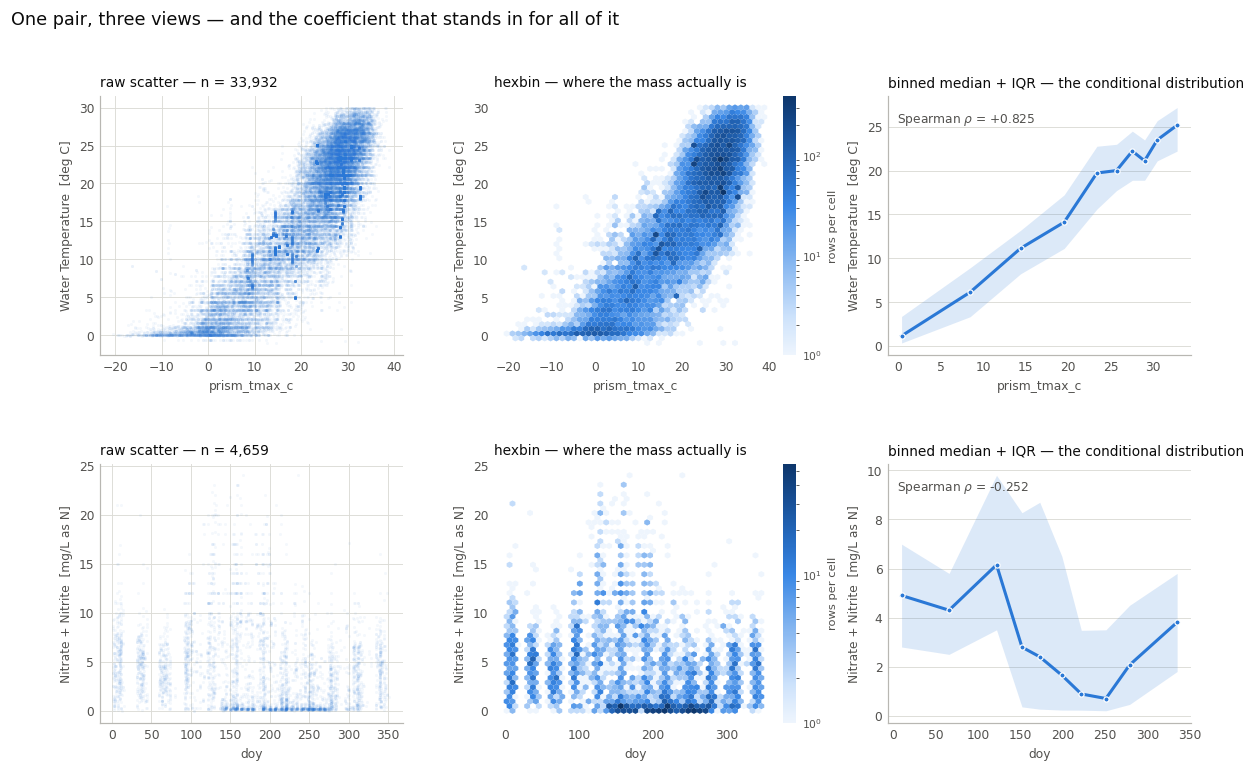

In [6]:
ANATOMY = [
    ("prism_tmax_c", "Water Temperature", None),
    ("doy", "Nitrate + Nitrite", None),
]

fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.4),
                         gridspec_kw={"hspace": 0.42, "wspace": 0.3})

for row, (xcol, tlabel, clip) in enumerate(ANATOMY):
    tcol = TARGET_COLS[tlabel]
    x, y = pair_xy(xcol, tcol)
    hi = np.quantile(y, 0.995)
    keep = y <= hi                                  # the top 0.5% would set the y-limits alone
    rho = stats.spearmanr(x, y).statistic
    ylab = f"{tlabel}  [{TARGET_UNIT[tlabel]}]"

    ax = axes[row, 0]
    ax.scatter(x[keep], y[keep], s=4, color=BLUE, alpha=0.05, linewidths=0, zorder=3)
    style_axes(ax, axis="both")
    ax.set_xlabel(xcol, fontsize=8); ax.set_ylabel(ylab, fontsize=8)
    ax.set_title(f"raw scatter — n = {len(x):,}", loc="left", fontsize=9)

    ax = axes[row, 1]
    hb = ax.hexbin(x[keep], y[keep], gridsize=44, cmap=SEQUENTIAL, norm=LogNorm(vmin=1),
                   linewidths=0, mincnt=1)
    cb = fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.02)
    cb.set_label("rows per cell", fontsize=7.5, color=INK_SOFT)
    cb.outline.set_visible(False); cb.ax.tick_params(labelsize=7, length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.set_xlabel(xcol, fontsize=8); ax.set_ylabel(ylab, fontsize=8)
    ax.set_title("hexbin — where the mass actually is", loc="left", fontsize=9)

    ax = axes[row, 2]
    profile_panel(ax, x, y, xcol, ylab)
    ax.set_title("binned median + IQR — the conditional distribution", loc="left", fontsize=9)
    ax.text(0.03, 0.94, r"Spearman $\rho$ = " f"{rho:+.3f}", transform=ax.transAxes,
            fontsize=8, color=INK_SOFT, va="top")

fig.suptitle("One pair, three views — and the coefficient that stands in for all of it",
             x=0.062, ha="left", fontsize=11.5, y=0.985)
plt.show()

The top row is what a correlation coefficient is designed for: monotone, tight and near-linear
over the whole range, and ρ = +0.83 is a fair one-line summary of it.

The bottom row is not. Nitrate + nitrite starts the year near 4.9 mg/L, climbs to **6.15** at
its mid-May peak, collapses to **0.70** by early autumn and recovers to 3.8 by December — a
nine-fold swing following the fertiliser-application and runoff cycle of a row-crop watershed.
Spearman scores that at **−0.25** and calls it "generally decreasing", which is true of the
middle of the curve and wrong about both ends. A model with any capacity at all can fit the
shape; the coefficient cannot even name it. Note also what the raw scatter alone would not
tell you: the vertical striping is the univariate notebook's reporting-precision finding
reappearing as joint structure, and the solid floor along the bottom is its zero-inflation.

**So the numbers this notebook reports per pair are:** the shape class, how far the response
moves across the predictor's range *in the response's own units*, the largest
single-observation influence, the cluster-robust standard error, and the sample size the pair
is actually computed on. `outputs/bv_pair_profiles.csv` carries them for every target ×
feature pair.

## 2. Numeric ↔ numeric

### 2.1 The joint density atlas

Each target against the feature it correlates with most strongly, drawn as a density rather
than a scatter. Axes are logged where the univariate notebook found the variable spans orders
of magnitude, because a linear axis on a log-normal variable puts 99% of the data in the first
5% of the panel.

In [7]:
# Spearman for every target x feature pair, computed pairwise-complete, as the ordering key.
rho_rows = []
for tlabel, tcol in TARGET_COLS.items():
    for f in FEATURE_COLS:
        v = bv[[tcol, f]].dropna()
        if len(v) < 200:
            rho_rows.append({"target": tlabel, "feature": f, "n": len(v), "rho": np.nan})
            continue
        rho_rows.append({"target": tlabel, "feature": f, "n": len(v),
                         "rho": stats.spearmanr(v[tcol], v[f]).statistic})
rho_tbl = pd.DataFrame(rho_rows)
rho_tbl["abs_rho"] = rho_tbl["rho"].abs()

best = (rho_tbl.sort_values("abs_rho", ascending=False)
        .groupby("target", observed=True).head(1).set_index("target"))
best = best.reindex(sorted(TARGET_COLS, key=lambda t: -best.loc[t, "abs_rho"]))
print(best[["feature", "rho", "n"]].to_string(float_format=lambda v: f"{v:+.3f}"))

                                         feature    rho      n
target                                                        
Water Temperature                   prism_tmin_c +0.849  33953
Nitrate                                 pct_corn +0.489  12348
Dissolved Oxygen                    prism_tmin_c -0.442  31825
Nitrite                      npfert__n__total_kg +0.353  11611
Total Dissolved Solids           LatitudeMeasure +0.352  18011
Nitrate + Nitrite                        doy_sin +0.316   4659
Turbidity               streamflow_discharge_cfs +0.314  11775
pH                                isu_max_feel_c +0.299  29250
E. coli                                 awc_mean +0.296   7743
Specific Conductance         npfert__n__total_kg +0.291  16067
Total Suspended Solids  streamflow_discharge_cfs +0.290   6369
Total Phosphorus        streamflow_discharge_cfs +0.209   2590


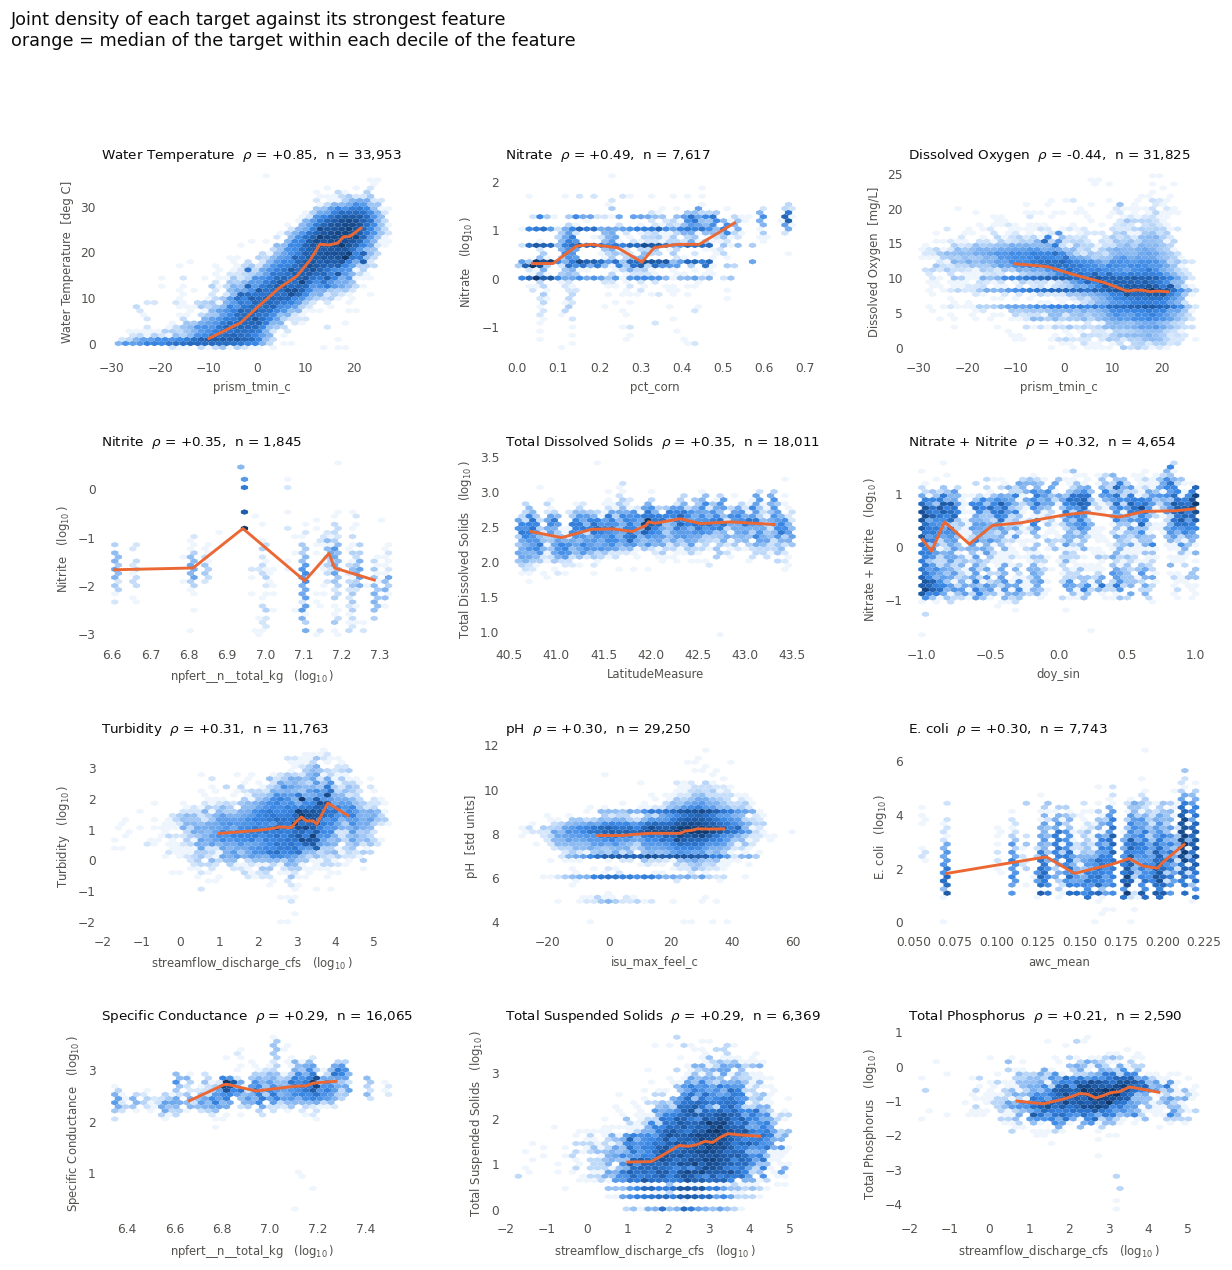

In [8]:
# Targets whose univariate distribution spans orders of magnitude get a log y-axis;
# same rule for the features.
LOG_TARGETS = {"E. coli", "Total Suspended Solids", "Turbidity", "Total Phosphorus",
               "Nitrate", "Nitrite", "Nitrate + Nitrite", "Specific Conductance",
               "Total Dissolved Solids"}
LOG_FEATURES = {"streamflow_discharge_cfs", "npmanure__total__n_kg", "npmanure__total__p_kg",
                "npfert__n__total_kg", "npfert__p__total_kg"}

fig, axes = plt.subplots(4, 3, figsize=(13.0, 12.4),
                         gridspec_kw={"hspace": 0.52, "wspace": 0.34})
for ax, tlabel in zip(axes.ravel(), best.index):
    fcol = best.loc[tlabel, "feature"]
    tcol = TARGET_COLS[tlabel]
    x, y = pair_xy(fcol, tcol)
    lx, ly = fcol in LOG_FEATURES, tlabel in LOG_TARGETS
    keep = np.ones(len(x), dtype=bool)
    if lx:
        keep &= x > 0
    if ly:
        keep &= y > 0
    x, y = x[keep], y[keep]
    xs = np.log10(x) if lx else x
    ys = np.log10(y) if ly else y
    hb = ax.hexbin(xs, ys, gridsize=38, cmap=SEQUENTIAL, norm=LogNorm(vmin=1),
                   linewidths=0, mincnt=1)
    # Overlay the conditional median so the shape reads off the density.
    p = binned_profile(xs, ys, bins=12)
    if p is not None:
        ax.plot(p["x_mid"], p["med"], color=ORANGE, linewidth=1.9, zorder=4)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    ax.set_xlabel(fcol + (r"   ($\log_{10}$)" if lx else ""), fontsize=7.6)
    ax.set_ylabel(f"{tlabel}" + (r"   ($\log_{10}$)" if ly else f"  [{TARGET_UNIT[tlabel]}]"),
                  fontsize=7.6)
    ax.set_title(f"{tlabel}  " r"$\rho$ = " f"{best.loc[tlabel, 'rho']:+.2f},  n = {len(x):,}",
                 loc="left", fontsize=8.8)

fig.suptitle("Joint density of each target against its strongest feature\n"
             "orange = median of the target within each decile of the feature",
             x=0.062, ha="left", fontsize=11.5, y=0.995)
plt.show()

### 2.2 A shape census over all 360 pairs

Looking at twelve pairs is not a survey. The conditional-median curve can be computed for
every target × feature pair and classified mechanically, which turns "what shape is it" into a
countable property of the whole table.

The rule, applied to the conditional median over the feature's ten deciles. Thresholds are
expressed in units of the target's own spread, so targets on different scales are comparable,
and every claim of movement is also checked against the **sampling noise of a bin median**
(1.2533 σ/√n) so that a wiggle produced by 300 samples is not promoted to a shape.

| Class | Test |
|---|---|
| **flat** | the median moves less than 0.25 × the target's IQR, **or** less than twice the bin-median standard error — no movement that is either practically or statistically visible |
| **hump (∩)** / **valley (∪)** | the extremum is in an interior decile and both arms fall/rise by at least 0.30 of the total range *and* by more than the noise floor |
| **threshold** | monotone, but more than half the total movement happens in a single decile-to-decile step |
| **monotone ↑ / ↓** | the bin medians are monotone in rank (\|ρ\| ≥ 0.9 across bins) |
| **irregular** | real movement, no simple description |
| **too few levels** | the feature has too few distinct values to cut into deciles at all |

Targets whose interquartile range is zero — Nitrite is 84% zeros, so its IQR is exactly 0 —
would divide by zero here, so the scale falls back to the 10th-to-90th-percentile span and
then to the standard deviation. `flat`, `irregular` and `too few levels` are the three classes
a model cannot exploit through that feature alone.

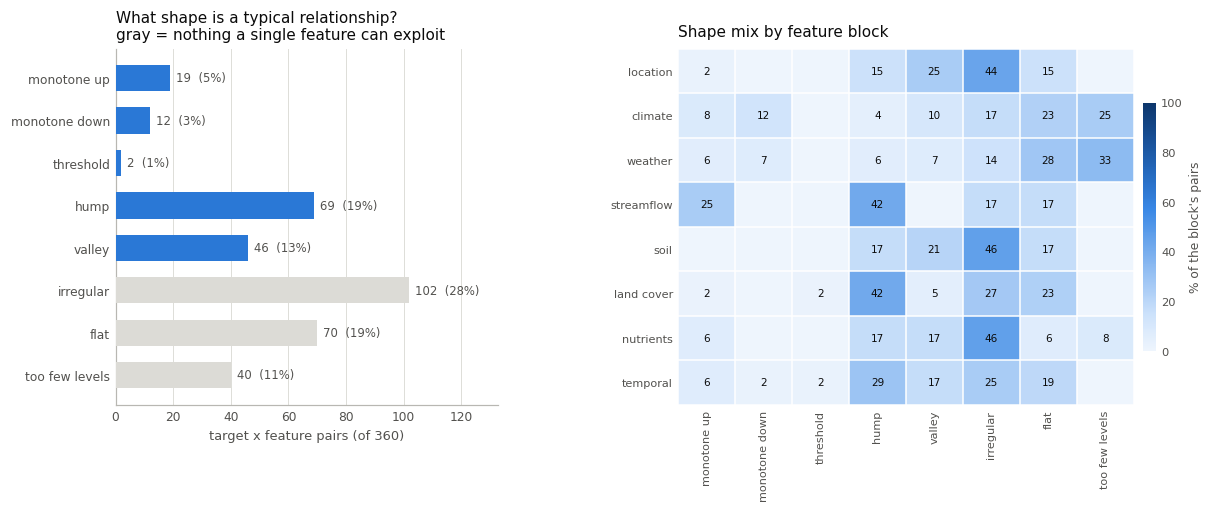

                pairs  median_abs_rho  median_range_over_scale
shape                                                         
monotone up        19           0.312                        1
monotone down      12           0.339                    1.171
threshold           2           0.364                      1.4
hump               69           0.076                      0.6
valley             46           0.131                     0.65
irregular         102           0.132                    0.552
flat               70           0.077                    0.209
too few levels     40           0.069                      NaN

212 of 360 pairs (59%) have no shape a single feature could be used on.
features too discrete to cut into deciles for at least one target: isu_snow_in, isu_snowd_in, npfert__n__total_kg, npfert__p__total_kg, prism_ppt_mm


In [9]:
def robust_scale(v):
    """A non-degenerate scale for the target. IQR unless the target is so zero-inflated
    that its IQR is exactly 0, then the p10-p90 span, then the standard deviation."""
    iqr = v.quantile(0.75) - v.quantile(0.25)
    if iqr > 0:
        return float(iqr), "IQR"
    span = v.quantile(0.90) - v.quantile(0.10)
    if span > 0:
        return float(span), "p10-p90"
    sd = v.std()
    return (float(sd) if sd > 0 else np.nan), "std"


def classify_shape(prof, scale, flat_frac=0.25, arm_frac=0.30, step_frac=0.50):
    """Label the shape of a conditional-median curve. See the table above for the rules."""
    med = prof["med"].to_numpy(float)
    k = len(med)
    if k < 5 or not np.isfinite(scale) or scale <= 0:
        return "too few levels", np.nan
    rng_med = med.max() - med.min()
    rel = rng_med / scale
    noise = 2 * float(np.nanmedian(prof["se_med"]))     # sampling noise of a bin median
    if rel < flat_frac or rng_med < noise:
        return "flat", rel
    rho_bins = stats.spearmanr(np.arange(k), med).statistic
    imax, imin = int(np.argmax(med)), int(np.argmin(med))
    arm_min = max(arm_frac * rng_med, noise)
    # Interior extremum with both arms genuinely descending/ascending -> single-peaked.
    if 0 < imax < k - 1 and min(med[imax] - med[0], med[imax] - med[-1]) >= arm_min:
        return "hump", rel
    if 0 < imin < k - 1 and min(med[0] - med[imin], med[-1] - med[imin]) >= arm_min:
        return "valley", rel
    if abs(rho_bins) >= 0.90:
        steps = np.abs(np.diff(med))
        if steps.max() >= step_frac * steps.sum():
            return "threshold", rel
        return "monotone up" if rho_bins > 0 else "monotone down", rel
    return "irregular", rel


SHAPE_ORDER = ["monotone up", "monotone down", "threshold", "hump", "valley",
               "irregular", "flat", "too few levels"]
UNUSABLE = {"flat", "irregular", "too few levels"}

prof_rows = []
target_scales = {}
for tlabel, tcol in TARGET_COLS.items():
    tv = bv[tcol].dropna()
    target_scales[tlabel] = robust_scale(tv)
    scale, scale_kind = target_scales[tlabel]
    for fcol in FEATURE_COLS:
        x, y = pair_xy(fcol, tcol)
        if len(x) < 200:
            continue
        p = binned_profile(x, y, bins=10)
        row = {"target": tlabel, "feature": fcol, "block": FEATURE_BLOCK[fcol], "n": len(x),
               "rho": stats.spearmanr(x, y).statistic, "target_scale": scale,
               "scale_kind": scale_kind, "unit": TARGET_UNIT[tlabel]}
        if p is None or len(p) < 5:
            # Recorded, not dropped: a feature too discrete to bin is a finding about the
            # feature, and silently omitting it would understate how many pairs are unusable.
            prof_rows.append({**row, "shape": "too few levels",
                              "n_bins": 0 if p is None else len(p)})
            continue
        shape, rel = classify_shape(p, scale)
        prof_rows.append({
            **row, "shape": shape, "n_bins": len(p),
            "median_range_over_scale": rel,
            "med_min": p["med"].min(), "med_max": p["med"].max(),
            "median_range_native": p["med"].max() - p["med"].min(),
            "y_at_lowest_decile": p["med"].iloc[0], "y_at_highest_decile": p["med"].iloc[-1],
            "x_lowest_decile": p["x_mid"].iloc[0], "x_highest_decile": p["x_mid"].iloc[-1],
        })
profiles = pd.DataFrame(prof_rows)
profiles["abs_rho"] = profiles["rho"].abs()
profiles.to_csv(OUT_DIR / "bv_pair_profiles.csv", index=False)

counts = profiles["shape"].value_counts().reindex(SHAPE_ORDER).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2), gridspec_kw={"wspace": 0.42,
                                                                "width_ratios": [1, 1.25]})
ax = axes[0]
o = counts.iloc[::-1]
ax.barh(o.index, o.values, height=0.62, zorder=3,
        color=[GRIDLINE if s in UNUSABLE else BLUE for s in o.index])
for s, v in zip(o.index, o.values):
    ax.text(v + 2, s, f"{v}  ({100 * v / counts.sum():.0f}%)", va="center", fontsize=7.6,
            color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, counts.max() * 1.3)
ax.set_xlabel(f"target x feature pairs (of {int(counts.sum())})")
ax.set_title("What shape is a typical relationship?\ngray = nothing a single feature can exploit",
             loc="left")

ax = axes[1]
ct = (pd.crosstab(profiles["block"], profiles["shape"])
      .reindex(index=BLOCK_ORDER, columns=[s for s in SHAPE_ORDER if s in counts.index])
      .fillna(0))
ct_pct = 100 * ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)
im = heatmap(ct_pct, ax, cmap=SEQUENTIAL, vmin=0, vmax=100, annot_at=0.5, fmt="{:.0f}",
             fontsize=7.4, light_text_above=0.55)
add_colorbar(fig, im, ax, "% of the block's pairs")
ax.set_title("Shape mix by feature block", loc="left", pad=8)
plt.show()

print(profiles.groupby("shape", observed=True)
      .agg(pairs=("shape", "size"), median_abs_rho=("abs_rho", "median"),
           median_range_over_scale=("median_range_over_scale", "median"))
      .reindex(SHAPE_ORDER).dropna(how="all").round(3).to_string())
print(f"\n{int(profiles['shape'].isin(UNUSABLE).sum())} of {len(profiles)} pairs "
      f"({100 * profiles['shape'].isin(UNUSABLE).mean():.0f}%) have no shape a single feature "
      f"could be used on.")
print("features too discrete to cut into deciles for at least one target:",
      ", ".join(sorted(profiles.loc[profiles["shape"] == "too few levels", "feature"].unique())))

The classes are not equally useful, and the correlation coefficient cannot tell them apart. A
`hump` and a `flat` can both score ρ ≈ 0; a `threshold` and a `monotone up` can both score
ρ ≈ 0.5 while implying completely different behaviour outside the observed range. One example
of each class, drawn from the pairs where the shape is clearest:

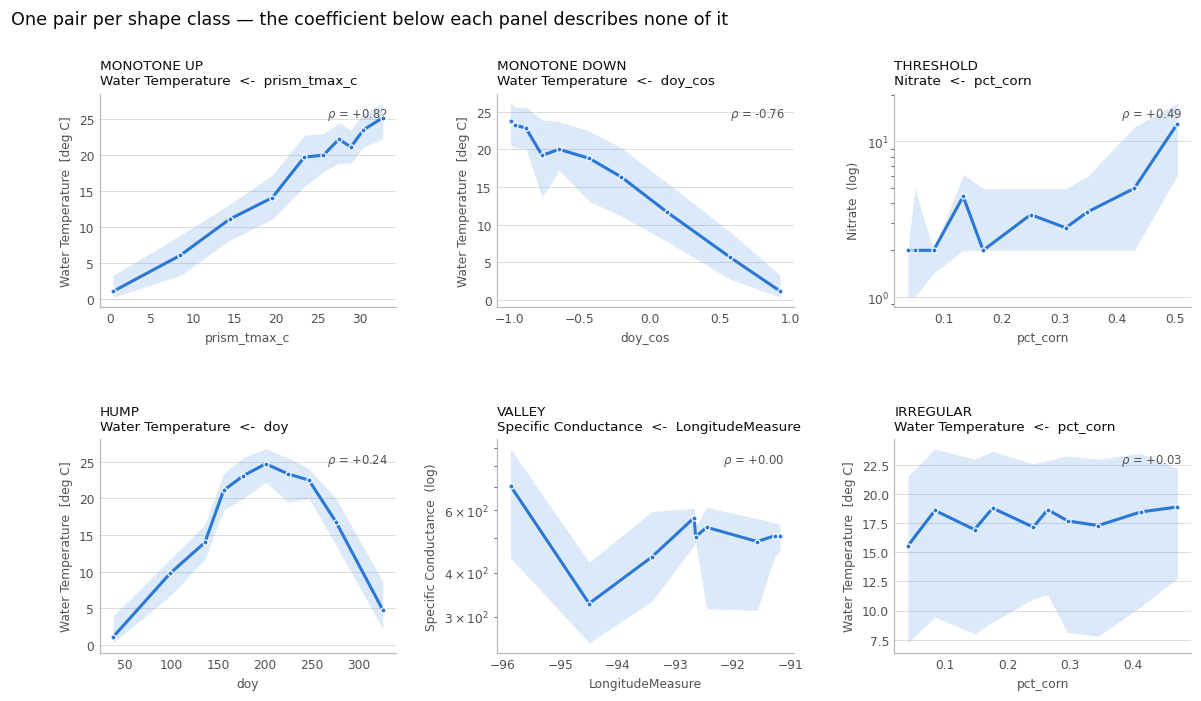

In [10]:
gallery = []
for shape in [s for s in SHAPE_ORDER if s in set(profiles["shape"])][:6]:
    sub = profiles[profiles["shape"] == shape]
    if shape in UNUSABLE:
        pick = sub.nlargest(1, "n")                    # most-observed, so it is not noise
    else:
        pick = sub.nlargest(1, "median_range_over_scale")
    gallery.append((shape, pick.iloc[0]))

fig, axes = plt.subplots(2, 3, figsize=(12.8, 6.6),
                         gridspec_kw={"hspace": 0.62, "wspace": 0.34})
for ax, (shape, r) in zip(axes.ravel(), gallery):
    x, y = pair_xy(r["feature"], TARGET_COLS[r["target"]])
    ly = r["target"] in LOG_TARGETS
    if ly:
        keep = y > 0
        x, y = x[keep], y[keep]
    p = profile_panel(ax, x, y, r["feature"],
                      f"{r['target']}" + ("  (log)" if ly else f"  [{r['unit']}]"), logy=ly)
    ax.set_title(f"{shape.upper()}\n{r['target']}  <-  {r['feature']}", loc="left", fontsize=8.8)
    ax.text(0.97, 0.94, r"$\rho$ = " f"{r['rho']:+.2f}", transform=ax.transAxes, ha="right",
            va="top", fontsize=7.6, color=INK_SOFT)
for ax in axes.ravel()[len(gallery):]:
    ax.set_axis_off()
fig.suptitle("One pair per shape class — the coefficient below each panel describes none of it",
             x=0.062, ha="left", fontsize=11.5, y=0.995)
plt.show()

### 2.3 Effect size in the units the variable is measured in

A correlation of 0.4 is not an amount of anything. The quantity a person can act on is: *across
the range of this predictor, how far does the response move, in mg/L or °C or MPN/100 mL?*
That number is read straight off the conditional-median curve — no model, no linearity
assumption, no distributional assumption — as the difference between the highest and lowest
decile median. The full range is used rather than the two endpoints because for a hump or a
valley the endpoints are the two places where the curve has *come back*, and differencing them
reports a large effect as a small one.

It is given natively and as a multiple of the target's own spread, so pairs belonging to
different targets can be ranked against each other.

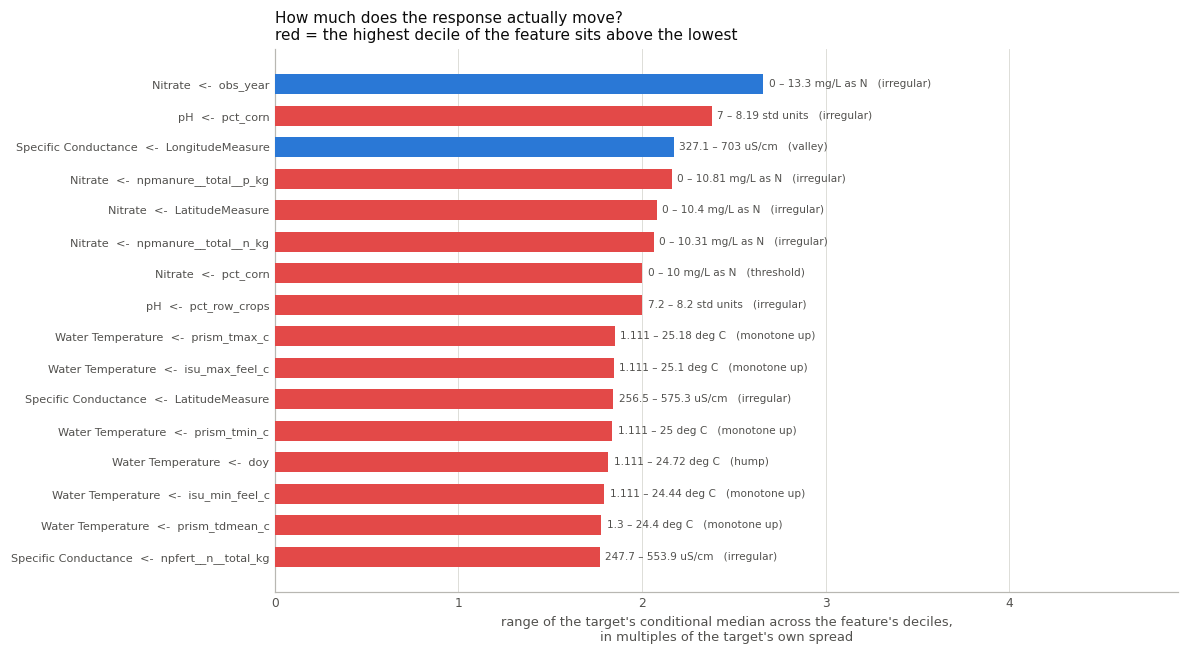

              target               feature      rho       shape  x_lowest_decile  x_highest_decile  med_min  med_max  median_range_over_scale      unit
             Nitrate              obs_year    -0.19   irregular         2.02e+03          2.02e+03        0     13.3                     2.66 mg/L as N
                  pH              pct_corn    0.161   irregular           0.0393             0.473        7     8.19                     2.38 std units
Specific Conductance      LongitudeMeasure 0.000721      valley            -95.9             -91.2      327      703                     2.17     uS/cm
             Nitrate npmanure__total__p_kg    0.277   irregular         1.31e+05          4.04e+06        0     10.8                     2.16 mg/L as N
             Nitrate       LatitudeMeasure      0.4   irregular             41.5              42.3        0     10.4                     2.08 mg/L as N
             Nitrate npmanure__total__n_kg    0.277   irregular         4.52e+05        

In [11]:
eff = profiles[~profiles["shape"].isin({"flat", "too few levels"})].copy()
top = eff.nlargest(16, "median_range_over_scale").sort_values("median_range_over_scale")

fig, ax = plt.subplots(figsize=(10.6, 6.4))
ax.barh(np.arange(len(top)), top["median_range_over_scale"], height=0.64, zorder=3,
        color=[RED if v > 0 else BLUE
               for v in (top["y_at_highest_decile"] - top["y_at_lowest_decile"])])
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels([f"{t}  <-  {f}" for t, f in zip(top["target"], top["feature"])], fontsize=7.4)
for i, r in enumerate(top.itertuples()):
    ax.text(r.median_range_over_scale + 0.03, i,
            f"{r.med_min:,.4g} – {r.med_max:,.4g} {r.unit}   ({r.shape})", va="center",
            fontsize=6.9, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, top["median_range_over_scale"].max() * 1.85)
ax.set_xlabel("range of the target's conditional median across the feature's deciles,\n"
              "in multiples of the target's own spread")
ax.set_title("How much does the response actually move?\n"
             "red = the highest decile of the feature sits above the lowest", loc="left")
plt.show()

print(eff.nlargest(12, "median_range_over_scale")[
    ["target", "feature", "rho", "shape", "x_lowest_decile", "x_highest_decile",
     "med_min", "med_max", "median_range_over_scale", "unit"]]
    .to_string(index=False, float_format=lambda v: f"{v:,.3g}"))

Ranking by effect size and ranking by correlation do not produce the same list. Correlation
rewards *consistency* — a small, perfectly reliable shift outranks a large, noisy one — while
the swing rewards *magnitude*. Where the two disagree, the pair is either a large effect that
only appears at one end of the feature's range, or a tidy relationship that barely moves the
response at all.

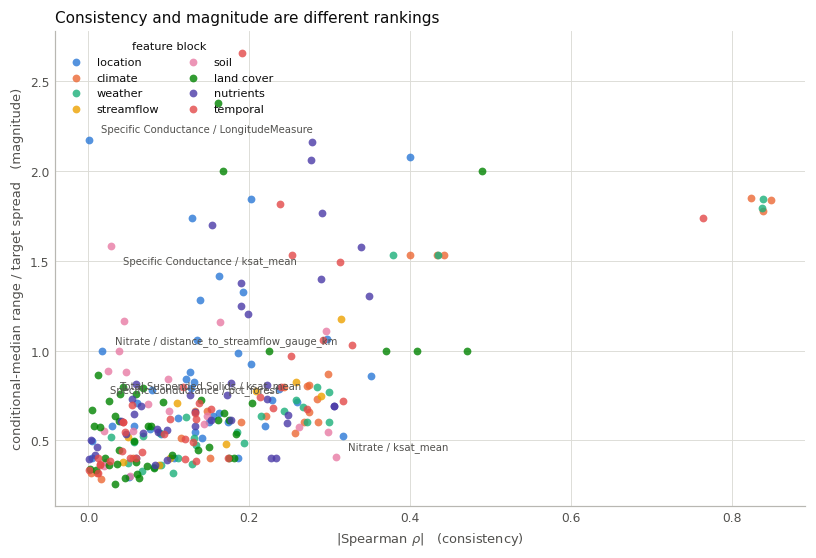

Spearman between the two rankings across 250 pairs with a usable shape: +0.564


In [12]:
r = eff.dropna(subset=["abs_rho", "median_range_over_scale"])
fig, ax = plt.subplots(figsize=(8.8, 5.6))
for blk in BLOCK_ORDER:
    s = r[r["block"] == blk]
    ax.scatter(s["abs_rho"], s["median_range_over_scale"], s=26, color=BLOCK_COLOR[blk],
               alpha=0.8, linewidths=0, zorder=3, label=blk)
# Label the pairs that disagree most between the two rankings.
r2 = r.assign(disagree=(r["median_range_over_scale"].rank(pct=True)
                        - r["abs_rho"].rank(pct=True)).abs())
for k, (_, row) in enumerate(r2.nlargest(6, "disagree").iterrows()):
    dx, dy = (8, 5) if k % 2 == 0 else (8, -11)
    ax.annotate(f"{row['target']} / {row['feature']}",
                (row["abs_rho"], row["median_range_over_scale"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=6.6, color=INK_SOFT)
style_axes(ax, axis="both")
ax.set_xlabel(r"|Spearman $\rho$|   (consistency)")
ax.set_ylabel("conditional-median range / target spread   (magnitude)")
ax.set_title("Consistency and magnitude are different rankings", loc="left")
ax.legend(fontsize=7.4, loc="upper left", ncol=2, title="feature block", title_fontsize=7.4)
plt.show()

print(f"Spearman between the two rankings across {len(r)} pairs with a usable shape: "
      f"{r['abs_rho'].corr(r['median_range_over_scale'], method='spearman'):+.3f}")

### 2.4 The other half of a relationship: spread

A conditional median describes where the response sits. It says nothing about how tightly, and
the two are independent properties of a pair. If the interquartile range of the target grows
with the feature, then squared-error training is being dominated by one end of the predictor's
range, and a single global error metric is averaging two different regimes.

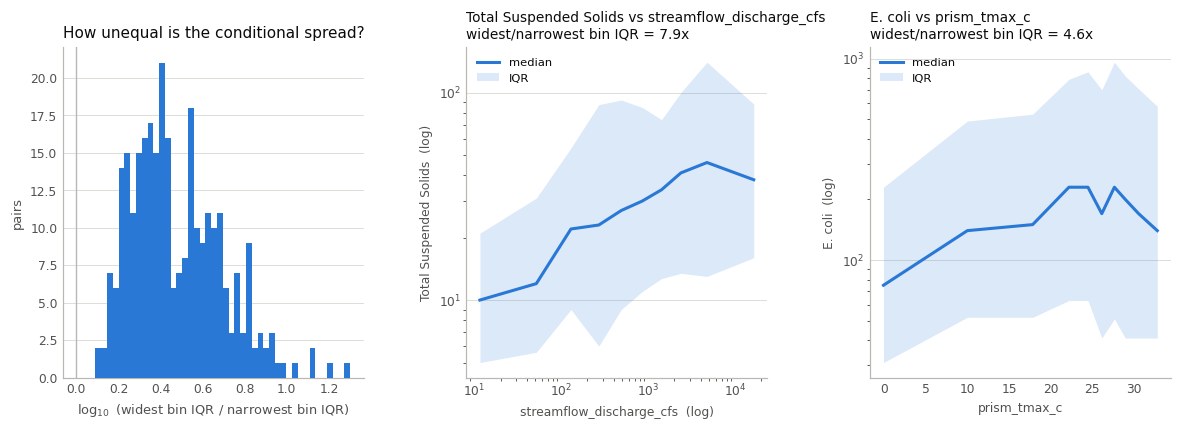

pairs where the conditional IQR varies by more than 3x across the feature's range: 126 of 292 (43%)
pairs where the spread grows monotonically with the feature (trend rho >= 0.8): 21

Most heteroskedastic pairs:
                target               feature  iqr_ratio  iqr_trend     n
               Nitrate              awc_mean      20.00      -0.42 10507
               E. coli      LongitudeMeasure      15.91       0.62 15898
               E. coli              awc_mean      13.53       0.53  7743
               Nitrate             ksat_mean      13.20       0.35 10507
Total Suspended Solids             ksat_mean      10.95      -0.26  2381
  Specific Conductance      LongitudeMeasure       9.38      -0.53 16067
Total Dissolved Solids             ksat_mean       9.31      -0.03  5100
               E. coli npmanure__total__p_kg       8.38       0.19 15898


In [13]:
spread_rows = []
for tlabel, tcol in TARGET_COLS.items():
    for fcol in FEATURE_COLS:
        x, y = pair_xy(fcol, tcol)
        if len(x) < 400:
            continue
        p = binned_profile(x, y, bins=10)
        if p is None or len(p) < 6:
            continue
        iqr = (p["q3"] - p["q1"]).to_numpy(float)
        if np.nanmin(iqr) <= 0:
            continue
        spread_rows.append({
            "target": tlabel, "feature": fcol, "block": FEATURE_BLOCK[fcol],
            "iqr_ratio": float(np.nanmax(iqr) / np.nanmin(iqr)),
            "iqr_trend": stats.spearmanr(np.arange(len(iqr)), iqr).statistic,
            "n": len(x),
        })
spread = pd.DataFrame(spread_rows)
spread.to_csv(OUT_DIR / "bv_conditional_spread.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.9), gridspec_kw={"wspace": 0.34})

ax = axes[0]
ax.hist(np.log10(spread["iqr_ratio"]), bins=44, color=BLUE, zorder=3)
ax.axvline(0, color=AXISLINE, linewidth=0.9, zorder=2)
style_axes(ax)
ax.set_xlabel(r"$\log_{10}$ (widest bin IQR / narrowest bin IQR)")
ax.set_ylabel("pairs")
ax.set_title("How unequal is the conditional spread?", loc="left")

SHOW = [("streamflow_discharge_cfs", "Total Suspended Solids", True),
        ("prism_tmax_c", "E. coli", False)]
for ax, (fcol, tlabel, lx) in zip(axes[1:], SHOW):
    x, y = pair_xy(fcol, TARGET_COLS[tlabel])
    if lx:
        keep = x > 0
        x, y = x[keep], y[keep]
    p = binned_profile(x, y, bins=10)
    ax.plot(p["x_mid"], p["med"], color=BLUE, linewidth=2, zorder=4, label="median")
    ax.fill_between(p["x_mid"], p["q1"], p["q3"], color=BLUE, alpha=0.16, linewidth=0,
                    zorder=2, label="IQR")
    if lx:
        ax.set_xscale("log")
    ax.set_yscale("log")
    style_axes(ax)
    ax.set_xlabel(fcol + ("  (log)" if lx else ""), fontsize=8)
    ax.set_ylabel(f"{tlabel}  (log)", fontsize=8)
    row = spread[(spread["target"] == tlabel) & (spread["feature"] == fcol)]
    ratio = row["iqr_ratio"].iloc[0] if len(row) else np.nan
    ax.set_title(f"{tlabel} vs {fcol}\nwidest/narrowest bin IQR = {ratio:,.1f}x",
                 loc="left", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper left")
plt.show()

print(f"pairs where the conditional IQR varies by more than 3x across the feature's range: "
      f"{int((spread['iqr_ratio'] > 3).sum())} of {len(spread)} "
      f"({100 * (spread['iqr_ratio'] > 3).mean():.0f}%)")
print(f"pairs where the spread grows monotonically with the feature (trend rho >= 0.8): "
      f"{int((spread['iqr_trend'] >= 0.8).sum())}")
print("\nMost heteroskedastic pairs:")
print(spread.nlargest(8, "iqr_ratio")[["target", "feature", "iqr_ratio", "iqr_trend", "n"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

## 3. How much can one pairwise number be trusted?

Three separate things can make a bivariate coefficient mean less than it appears to.

1. **The rows are not independent.** 1,345 stations produce 48,251 rows; the median station
   contributes 7 observations and the busiest contributes 2,878. Repeat visits to the same
   site are far more alike than two rows drawn at random, so the *effective* sample size is
   much smaller than `n`, and every standard error computed as if rows were independent is too
   small.
2. **360 pairs are being examined at once.** At the conventional 5% threshold, 18 of them
   would clear it by chance alone.
3. **One observation can carry the coefficient.** The univariate notebook found a single
   *E. coli* reading of 2,420,000 MPN/100 mL, ~1,000× the method ceiling. Pearson correlations
   involving that column are partly a statement about that one row.

### 3.1 Standard errors that respect the station structure

Spearman's ρ is the Pearson correlation of the ranks, so it is a mean of the per-row products
of standardised ranks and has an influence function

$$\psi_i = \tilde{x}_i\tilde{y}_i - \tfrac{\rho}{2}\left(\tilde{x}_i^2 + \tilde{y}_i^2\right)$$

Summing ψ *within a station* first and then across stations — the cluster-robust sandwich —
gives a standard error that counts a station once rather than counting each of its visits.
The ratio of that variance to the independent-rows variance is the **design effect**, and
`n / design effect` is the number of independent observations the pair is really worth.

In [14]:
def cluster_rho(x, y, groups, min_n=200):
    """Spearman rho with an independent-rows SE and a station-cluster-robust SE."""
    n = len(x)
    if n < min_n:
        return None
    rx = stats.rankdata(x)
    ry = stats.rankdata(y)
    xs = (rx - rx.mean()) / rx.std()
    ys = (ry - ry.mean()) / ry.std()
    rho = float((xs * ys).mean())
    psi = xs * ys - 0.5 * rho * (xs ** 2 + ys ** 2)      # mean-zero by construction
    var_iid = float((psi ** 2).sum()) / n ** 2
    cluster_sums = pd.Series(psi).groupby(np.asarray(groups), observed=True).sum().to_numpy()
    var_clu = float((cluster_sums ** 2).sum()) / n ** 2
    se_iid, se_clu = np.sqrt(var_iid), np.sqrt(var_clu)
    deff = var_clu / var_iid if var_iid > 0 else np.nan
    return {"n": n, "n_stations": len(cluster_sums), "rho": rho,
            "se_iid": se_iid, "se_cluster": se_clu, "design_effect": deff,
            "n_eff": n / deff if deff and np.isfinite(deff) and deff > 0 else np.nan,
            "ci_lo": rho - 1.96 * se_clu, "ci_hi": rho + 1.96 * se_clu,
            "z_iid": rho / se_iid if se_iid > 0 else np.nan,
            "z_cluster": rho / se_clu if se_clu > 0 else np.nan}


rel_rows = []
for tlabel, tcol in TARGET_COLS.items():
    for fcol in FEATURE_COLS:
        v = bv[[ID_COL, tcol, fcol]].dropna()
        r = cluster_rho(v[tcol].to_numpy(float), v[fcol].to_numpy(float), v[ID_COL].to_numpy())
        if r is None:
            continue
        r.update({"target": tlabel, "feature": fcol, "block": FEATURE_BLOCK[fcol]})
        rel_rows.append(r)
reliab = pd.DataFrame(rel_rows)
reliab["p_iid"] = 2 * stats.norm.sf(np.abs(reliab["z_iid"]))
reliab["p_cluster"] = 2 * stats.norm.sf(np.abs(reliab["z_cluster"]))
print(f"{len(reliab)} pairs; median design effect {reliab['design_effect'].median():.1f}, "
      f"max {reliab['design_effect'].max():.1f}")
print(f"median n {reliab['n'].median():,.0f}  ->  median effective n "
      f"{reliab['n_eff'].median():,.0f}")

360 pairs; median design effect 18.3, max 165.0
median n 15,850  ->  median effective n 1,006


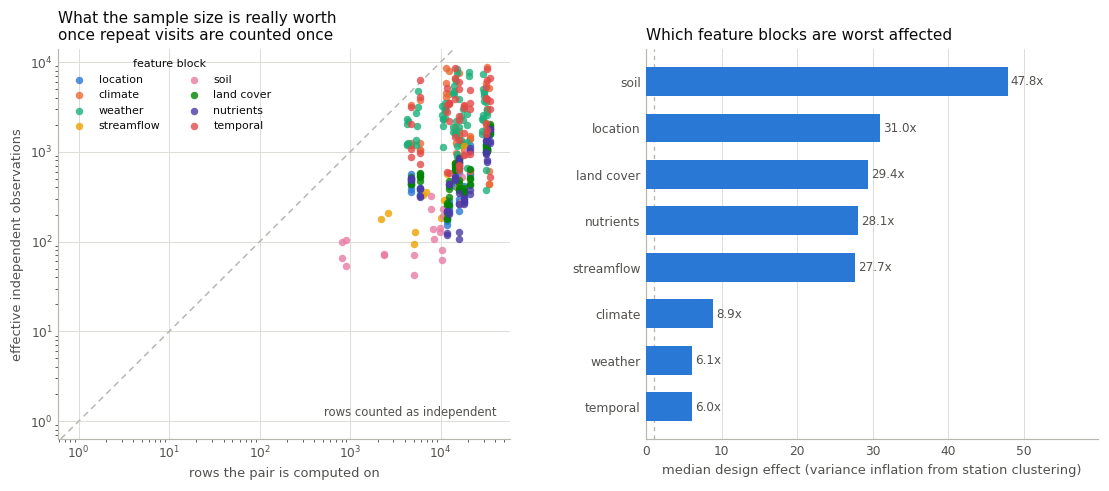

                target             feature     n  n_stations     rho  se_iid  se_cluster  design_effect  n_eff
  Specific Conductance           ksat_mean 10206         242 -0.0282  0.0102        0.13            165   61.8
  Specific Conductance npfert__p__total_kg 16067         483    0.29 0.00745      0.0909            149    108
  Specific Conductance            awc_mean 10205         241 -0.0193  0.0113       0.126            126   80.9
  Specific Conductance npfert__n__total_kg 16067         483   0.291 0.00749      0.0841            126    128
Total Dissolved Solids           ksat_mean  5100         258  0.0375  0.0153       0.168            121   42.2
               Nitrite npfert__n__total_kg 11611         229   0.353  0.0163       0.162           98.7    118
               Nitrite npfert__p__total_kg 11611         229   0.311  0.0168       0.163           93.1    125
     Water Temperature      isu_min_feel_c 31619         922   0.837 0.00177      0.0162           83.5    379


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), gridspec_kw={"wspace": 0.3})

ax = axes[0]
for blk in BLOCK_ORDER:
    s = reliab[reliab["block"] == blk]
    ax.scatter(s["n"], s["n_eff"], s=24, color=BLOCK_COLOR[blk], alpha=0.8, linewidths=0,
               zorder=3, label=blk)
ax.axline((1, 1), slope=1, color=AXISLINE, linewidth=1, linestyle=(0, (4, 3)), zorder=2)
ax.text(0.97, 0.06, "rows counted as independent", transform=ax.transAxes, ha="right",
        fontsize=7.6, color=INK_SOFT)
ax.set_xscale("log"); ax.set_yscale("log")
style_axes(ax, axis="both")
ax.set_xlabel("rows the pair is computed on")
ax.set_ylabel("effective independent observations")
ax.set_title("What the sample size is really worth\nonce repeat visits are counted once",
             loc="left")
ax.legend(fontsize=7.2, loc="upper left", ncol=2, title="feature block", title_fontsize=7.2)

ax = axes[1]
d = (reliab.groupby("block", observed=True)["design_effect"].median()
     .reindex(BLOCK_ORDER).sort_values())
ax.barh(d.index, d.values, color=BLUE, height=0.62, zorder=3)
for b, v in zip(d.index, d.values):
    ax.text(v + 0.4, b, f"{v:,.1f}x", va="center", fontsize=7.8, color=INK_SOFT)
ax.axvline(1, color=AXISLINE, linewidth=0.9, linestyle=(0, (3, 3)), zorder=2)
style_axes(ax, axis="x")
ax.set_xlim(0, d.max() * 1.25)
ax.set_xlabel("median design effect (variance inflation from station clustering)")
ax.set_title("Which feature blocks are worst affected", loc="left")
plt.show()

print(reliab.nlargest(8, "design_effect")[
    ["target", "feature", "n", "n_stations", "rho", "se_iid", "se_cluster",
     "design_effect", "n_eff"]].to_string(index=False, float_format=lambda v: f"{v:,.3g}"))

The sandwich formula is an asymptotic approximation, so it is worth checking against the thing
it approximates. A **cluster bootstrap** — resampling whole stations with replacement, 400
times — makes no such approximation. If the two agree, the fast estimator can be trusted for
all 360 pairs.

In [16]:
rng = np.random.default_rng(7)
N_BOOT = 400
CHECK = [("Water Temperature", "prism_tmax_c"), ("Nitrate", "pct_corn"),
         ("Specific Conductance", "streamflow_discharge_cfs"), ("E. coli", "doy")]

check_rows = []
for tlabel, fcol in CHECK:
    v = bv[[ID_COL, TARGET_COLS[tlabel], fcol]].dropna()
    x = stats.rankdata(v[TARGET_COLS[tlabel]].to_numpy(float))
    y = stats.rankdata(v[fcol].to_numpy(float))
    codes, uniq = pd.factorize(v[ID_COL].to_numpy())
    order = np.argsort(codes, kind="stable")
    x, y, codes = x[order], y[order], codes[order]
    starts = np.searchsorted(codes, np.arange(len(uniq)))
    ends = np.searchsorted(codes, np.arange(len(uniq)), side="right")
    idx_by_station = [np.arange(s, e) for s, e in zip(starts, ends)]

    boots = np.empty(N_BOOT)
    for b in range(N_BOOT):
        pick = rng.integers(0, len(uniq), len(uniq))
        sel = np.concatenate([idx_by_station[i] for i in pick])
        xb, yb = x[sel], y[sel]                      # ranks fixed: a Pearson-on-ranks bootstrap
        boots[b] = np.corrcoef(xb, yb)[0, 1]
    a = reliab[(reliab["target"] == tlabel) & (reliab["feature"] == fcol)].iloc[0]
    check_rows.append({"target": tlabel, "feature": fcol, "rho": a["rho"],
                       "se_iid": a["se_iid"], "se_sandwich": a["se_cluster"],
                       "se_bootstrap": boots.std(ddof=1),
                       "boot_ci_lo": np.quantile(boots, 0.025),
                       "boot_ci_hi": np.quantile(boots, 0.975)})
check = pd.DataFrame(check_rows)
print(check.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nsandwich / bootstrap SE ratio: "
      f"{(check['se_sandwich'] / check['se_bootstrap']).round(2).tolist()}")

              target                  feature     rho  se_iid  se_sandwich  se_bootstrap  boot_ci_lo  boot_ci_hi
   Water Temperature             prism_tmax_c  0.8246  0.0018       0.0134        0.0139      0.7957      0.8484
             Nitrate                 pct_corn  0.4891  0.0071       0.0401        0.0422      0.3957      0.5647
Specific Conductance streamflow_discharge_cfs -0.1710  0.0104       0.0630        0.0810     -0.2988      0.0457
             E. coli                      doy  0.1482  0.0074       0.0122        0.0129      0.1215      0.1705

sandwich / bootstrap SE ratio: [0.96, 0.95, 0.78, 0.95]


### 3.2 Significance across 360 pairs at once

With cluster-robust standard errors in hand, each pair gets a p-value, and the whole family
gets a Benjamini–Hochberg false-discovery-rate correction. The comparison worth making is
between the naive count and the corrected one: how many of the "significant" relationships
survive both the clustering and the multiplicity.

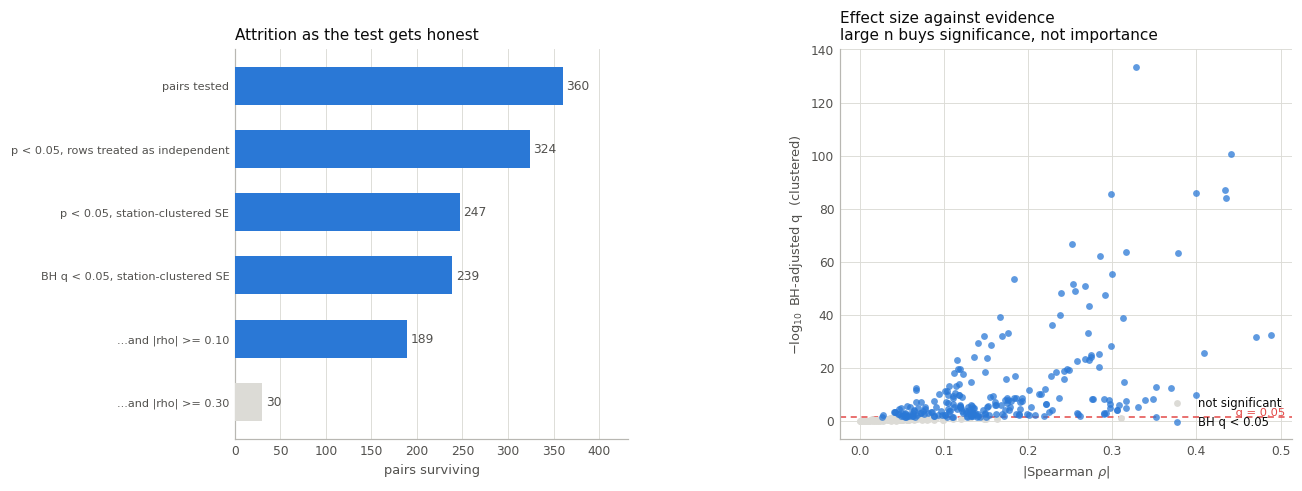

pairs tested                             360
p < 0.05, rows treated as independent    324
p < 0.05, station-clustered SE           247
BH q < 0.05, station-clustered SE        239
...and |rho| >= 0.10                     189
...and |rho| >= 0.30                      30

Significant but negligible (q < 0.05 and |rho| < 0.05):
                target      feature      rho     n  q_cluster
     Water Temperature     obs_year  0.02716 34705    0.03987
                    pH prism_ppt_mm -0.04632 32202   2.83e-05
                    pH          doy   0.0425 32353  0.0003333
               Nitrite prism_ppt_mm   0.0408 11495   0.000607
Total Dissolved Solids   isu_avg_rh -0.04976 16913    0.02051
Total Suspended Solids   isu_avg_rh  0.04713 13770   0.002978
Total Suspended Solids          doy -0.04255 14525  0.0003837
             Turbidity          doy -0.04575 21156   0.002978


In [17]:
def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values."""
    p = np.asarray(p, dtype=float)
    ok = np.isfinite(p)
    out = np.full(p.shape, np.nan)
    q = p[ok]
    order = np.argsort(q)
    ranked = q[order] * len(q) / (np.arange(len(q)) + 1)
    adj = np.minimum.accumulate(ranked[::-1])[::-1]
    res = np.empty(len(q))
    res[order] = np.clip(adj, 0, 1)
    out[ok] = res
    return out


reliab["q_iid"] = bh_fdr(reliab["p_iid"])
reliab["q_cluster"] = bh_fdr(reliab["p_cluster"])
reliab.to_csv(OUT_DIR / "bv_pair_reliability.csv", index=False)

steps = pd.Series({
    "pairs tested": len(reliab),
    "p < 0.05, rows treated as independent": int((reliab["p_iid"] < 0.05).sum()),
    "p < 0.05, station-clustered SE": int((reliab["p_cluster"] < 0.05).sum()),
    "BH q < 0.05, station-clustered SE": int((reliab["q_cluster"] < 0.05).sum()),
    "...and |rho| >= 0.10": int(((reliab["q_cluster"] < 0.05) & (reliab["rho"].abs() >= 0.10)).sum()),
    "...and |rho| >= 0.30": int(((reliab["q_cluster"] < 0.05) & (reliab["rho"].abs() >= 0.30)).sum()),
})

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6),
                         gridspec_kw={"wspace": 0.5, "width_ratios": [1, 1.15]})

ax = axes[0]
o = steps.iloc[::-1]
ax.barh(o.index, o.values, color=[GRIDLINE] + [BLUE] * (len(o) - 1), height=0.6, zorder=3)
for k, v in zip(o.index, o.values):
    ax.text(v + 4, k, f"{v}", va="center", fontsize=8, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, steps.max() * 1.2)
ax.tick_params(axis="y", labelsize=7.4)
ax.set_xlabel("pairs surviving")
ax.set_title("Attrition as the test gets honest", loc="left")

ax = axes[1]
sig = reliab["q_cluster"] < 0.05
ax.scatter(reliab.loc[~sig, "rho"].abs(), -np.log10(reliab.loc[~sig, "q_cluster"]),
           s=20, color=GRIDLINE, linewidths=0, zorder=3, label="not significant")
ax.scatter(reliab.loc[sig, "rho"].abs(), -np.log10(reliab.loc[sig, "q_cluster"]),
           s=20, color=BLUE, alpha=0.75, linewidths=0, zorder=4, label="BH q < 0.05")
ax.axhline(-np.log10(0.05), color=RED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=2)
ax.text(0.985, -np.log10(0.05), " q = 0.05", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=7.5, color=RED)
style_axes(ax, axis="both")
ax.set_xlabel(r"|Spearman $\rho$|")
ax.set_ylabel(r"$-\log_{10}$ BH-adjusted q  (clustered)")
ax.set_title("Effect size against evidence\nlarge n buys significance, not importance",
             loc="left")
ax.legend(fontsize=7.6, loc="lower right")
plt.show()

print(steps.to_string())
print("\nSignificant but negligible (q < 0.05 and |rho| < 0.05):")
tiny = reliab[(reliab["q_cluster"] < 0.05) & (reliab["rho"].abs() < 0.05)]
print(tiny[["target", "feature", "rho", "n", "q_cluster"]].head(8)
      .to_string(index=False, float_format=lambda v: f"{v:,.4g}") if len(tiny) else "  none")

### 3.3 How much of a coefficient is one row?

Leave-one-out influence, computed exactly: for each pair, recompute Pearson's *r* with each
observation removed in turn — cheap in closed form from the running sums — and record the
largest change. Pearson is the right coefficient to interrogate here precisely *because* it is
the fragile one; the same quantity for Spearman is bounded by construction, which is the
argument for using ranks in the first place.

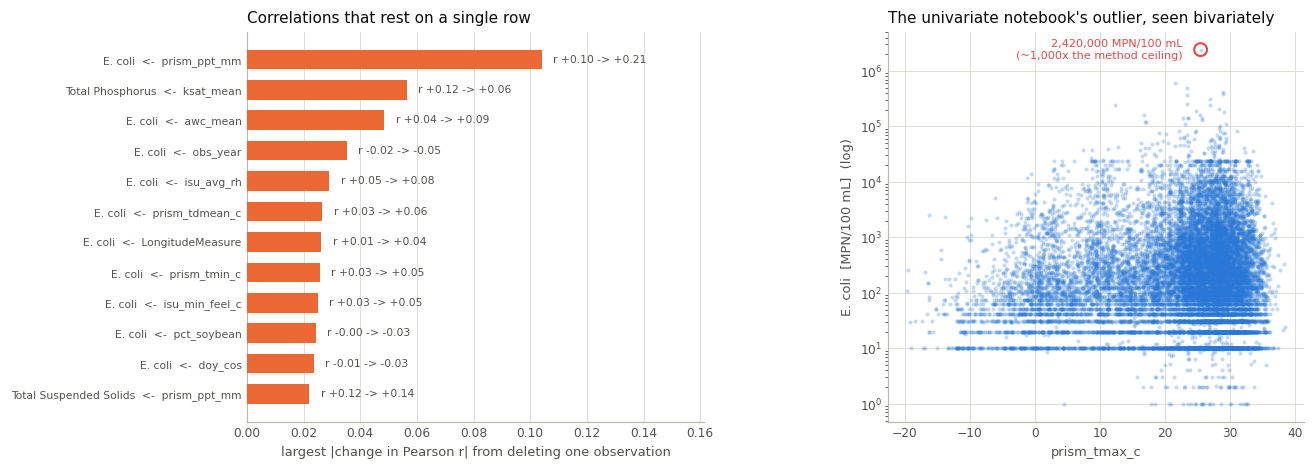

pairs where deleting one row moves Pearson r by more than 0.05: 2 of 360; by more than 0.02: 14
largest single-row effect anywhere: 0.104
the same quantity for Spearman is bounded by O(1/n) = 6.3e-05 at the median n of 15,850 — which is the argument for ranks in one line

Most influential single observations:
          target        feature  pearson  pearson_without_worst  spearman       worst_station  worst_target_value  worst_feature_value
         E. coli   prism_ppt_mm   0.1012                 0.2054    0.1836            ERG-RC13            2.42e+06               0.4417
Total Phosphorus      ksat_mean   0.1179                0.06146 -0.002225 21IOWA_WQX-14000452                 9.5                60.14
         E. coli       awc_mean  0.03811                0.08663     0.296            ERG-RC13            2.42e+06                 0.19
         E. coli       obs_year -0.01929               -0.05468   -0.1111            ERG-RC13            2.42e+06                2,023
         E. co

In [18]:
def loo_max_delta(x, y):
    """Largest change in Pearson r from deleting a single observation, and its index."""
    n = len(x)
    sx, sy = x.sum(), y.sum()
    sxx, syy, sxy = (x * x).sum(), (y * y).sum(), (x * y).sum()

    def r_from(n_, sx_, sy_, sxx_, syy_, sxy_):
        cov = sxy_ - sx_ * sy_ / n_
        vx = sxx_ - sx_ ** 2 / n_
        vy = syy_ - sy_ ** 2 / n_
        den = np.sqrt(np.clip(vx, 0, None) * np.clip(vy, 0, None))
        return np.where(den > 0, cov / np.where(den > 0, den, 1), np.nan)

    r_full = float(r_from(n, sx, sy, sxx, syy, sxy))
    r_loo = r_from(n - 1, sx - x, sy - y, sxx - x * x, syy - y * y, sxy - x * y)
    d = np.abs(r_loo - r_full)
    i = int(np.nanargmax(d))
    return r_full, float(r_loo[i]), float(d[i]), i


inf_rows = []
for tlabel, tcol in TARGET_COLS.items():
    for fcol in FEATURE_COLS:
        v = bv[[ID_COL, DATE_COL, tcol, fcol]].dropna()
        if len(v) < 200:
            continue
        r_full, r_wo, delta, i = loo_max_delta(v[tcol].to_numpy(float), v[fcol].to_numpy(float))
        rho = stats.spearmanr(v[tcol], v[fcol]).statistic
        inf_rows.append({
            "target": tlabel, "feature": fcol, "n": len(v),
            "pearson": r_full, "pearson_without_worst": r_wo, "max_abs_delta_r": delta,
            "spearman": rho,
            "worst_station": v[ID_COL].iloc[i], "worst_date": v[DATE_COL].iloc[i],
            "worst_target_value": v[tcol].iloc[i], "worst_feature_value": v[fcol].iloc[i],
        })
influence = pd.DataFrame(inf_rows)
influence.to_csv(OUT_DIR / "bv_leave_one_out_influence.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6),
                         gridspec_kw={"wspace": 0.42, "width_ratios": [1.1, 1]})

ax = axes[0]
worst = influence.nlargest(12, "max_abs_delta_r").sort_values("max_abs_delta_r")
ax.barh(np.arange(len(worst)), worst["max_abs_delta_r"], color=ORANGE, height=0.64, zorder=3)
ax.set_yticks(np.arange(len(worst)))
ax.set_yticklabels([f"{t}  <-  {f}" for t, f in zip(worst["target"], worst["feature"])],
                   fontsize=7)
for i, r in enumerate(worst.itertuples()):
    ax.text(r.max_abs_delta_r + 0.004, i, f"r {r.pearson:+.2f} -> {r.pearson_without_worst:+.2f}",
            va="center", fontsize=7, color=INK_SOFT)
style_axes(ax, axis="x")
ax.set_xlim(0, worst["max_abs_delta_r"].max() * 1.55)
ax.set_xlabel("largest |change in Pearson r| from deleting one observation")
ax.set_title("Correlations that rest on a single row", loc="left")

ax = axes[1]
tcol = TARGET_COLS["E. coli"]
v = bv[["prism_tmax_c", tcol]].dropna()
x, y = v["prism_tmax_c"].to_numpy(float), v[tcol].to_numpy(float)
ax.scatter(x, y, s=7, color=BLUE, alpha=0.28, linewidths=0, zorder=3)
j = int(np.argmax(y))
ax.scatter([x[j]], [y[j]], s=70, facecolor="none", edgecolor=RED, linewidth=1.4, zorder=5)
ax.annotate(f"{y[j]:,.0f} MPN/100 mL\n(~1,000x the method ceiling)", (x[j], y[j]),
            textcoords="offset points", xytext=(-12, -6), ha="right", fontsize=7.4, color=RED)
ax.set_yscale("log")
style_axes(ax, axis="both")
ax.set_xlabel("prism_tmax_c")
ax.set_ylabel("E. coli  [MPN/100 mL]  (log)")
ax.set_title("The univariate notebook's outlier, seen bivariately", loc="left")
plt.show()

print(f"pairs where deleting one row moves Pearson r by more than 0.05: "
      f"{int((influence['max_abs_delta_r'] > 0.05).sum())} of {len(influence)}; "
      f"by more than 0.02: {int((influence['max_abs_delta_r'] > 0.02).sum())}")
print(f"largest single-row effect anywhere: {influence['max_abs_delta_r'].max():.3f}")
print(f"the same quantity for Spearman is bounded by O(1/n) = "
      f"{1 / influence['n'].median():.1e} at the median n of "
      f"{influence['n'].median():,.0f} — which is the argument for ranks in one line")
print("\nMost influential single observations:")
print(influence.nlargest(6, "max_abs_delta_r")[
    ["target", "feature", "pearson", "pearson_without_worst", "spearman",
     "worst_station", "worst_target_value", "worst_feature_value"]]
    .to_string(index=False))

## 4. Numeric ↔ categorical

None of the analysis so far applies when one member of the pair is a label. `hydrologic_group`,
`drainage_class`, `MonitoringLocationTypeName`, `OrganizationIdentifier`, `ProviderName` and
`season` are all bivariate partners for a target, and a correlation matrix has no cell for
them.

The right summary is a **group-difference effect size**, not a coefficient. The Kruskal–Wallis
H test compares the rank distribution across groups without assuming normality or equal
variances; converting H to

$$\varepsilon^2 = \frac{H - k + 1}{n - k}$$

gives the share of the target's rank variance explained by group membership, on a 0–1 scale
directly comparable to a squared correlation. As in §3, the p-values are not to be trusted at
face value — the rows within a station are not independent, and most of these categoricals are
station attributes — so effect size is the number to read and significance is reported only as
a sanity check.

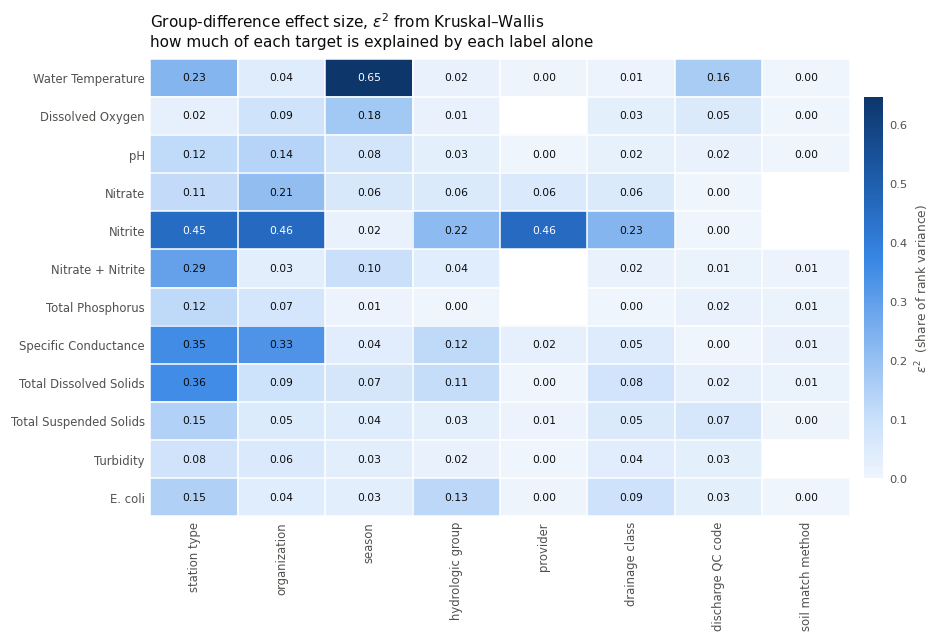

                target    categorical  k_groups     n  epsilon_sq  pct_stations_in_one_group
     Water Temperature         season         4 34705       0.647                       27.8
               Nitrite   organization         2 11602       0.459                        100
               Nitrite       provider         2 11611       0.455                        100
               Nitrite   station type         4 11572       0.454                        100
Total Dissolved Solids   station type         8 17983       0.356                        100
  Specific Conductance   station type         7 16029       0.352                        100
  Specific Conductance   organization         7 15992       0.332                        100
     Nitrate + Nitrite   station type         6  4647       0.291                        100
     Water Temperature   station type         9 34693       0.233                        100
               Nitrite drainage class         6  9876       0.233     

In [19]:
CATEGORICALS = ["season", "MonitoringLocationTypeName", "hydrologic_group", "drainage_class",
                "ProviderName", "OrganizationIdentifier", "streamflow_discharge_cd",
                "soil_match_method"]
CAT_LABEL = {"MonitoringLocationTypeName": "station type",
             "OrganizationIdentifier": "organization",
             "streamflow_discharge_cd": "discharge QC code",
             "soil_match_method": "soil match method",
             "hydrologic_group": "hydrologic group",
             "drainage_class": "drainage class",
             "ProviderName": "provider"}

cat_rows = []
for tlabel, tcol in TARGET_COLS.items():
    for ccol in CATEGORICALS:
        v = df[[tcol, ccol, ID_COL]].dropna()
        if len(v) < 200:
            continue
        groups = [g[tcol].to_numpy(float) for _, g in v.groupby(ccol, observed=True)
                  if len(g) >= 30]
        k = len(groups)
        if k < 2:
            continue
        H = stats.kruskal(*groups).statistic
        n = sum(len(g) for g in groups)
        eps2 = max((H - k + 1) / (n - k), 0.0)
        # How much of the group structure is just "which stations are in which group"?
        station_purity = (v.groupby(ID_COL, observed=True)[ccol].nunique() == 1).mean()
        cat_rows.append({"target": tlabel, "categorical": CAT_LABEL.get(ccol, ccol),
                         "column": ccol, "k_groups": k, "n": n, "epsilon_sq": eps2,
                         "H": H, "p": stats.kruskal(*groups).pvalue,
                         "pct_stations_in_one_group": 100 * station_purity})
cat_eff = pd.DataFrame(cat_rows)
cat_eff.to_csv(OUT_DIR / "bv_categorical_effect_size.csv", index=False)

mat = (cat_eff.pivot(index="target", columns="categorical", values="epsilon_sq")
       .reindex(index=list(TARGET_COLS)))
mat = mat[mat.mean().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.6, 5.4))
im = heatmap(mat, ax, cmap=SEQUENTIAL, vmin=0, vmax=float(np.nanmax(mat.to_numpy())),
             annot_at=0.0, fmt="{:.2f}", fontsize=7.6, light_text_above=0.55)
add_colorbar(fig, im, ax, r"$\varepsilon^2$  (share of rank variance)")
ax.set_title(r"Group-difference effect size, $\varepsilon^2$ from Kruskal–Wallis"
             "\nhow much of each target is explained by each label alone", loc="left", pad=8)
plt.show()

print(cat_eff.nlargest(10, "epsilon_sq")[
    ["target", "categorical", "k_groups", "n", "epsilon_sq", "pct_stations_in_one_group"]]
    .to_string(index=False, float_format=lambda v: f"{v:,.3g}"))

The two columns that dominate — organization and station type — are **not** measurements of the
water. They are measurements of *who sampled it and what kind of place it is*, and the last
column of the table above says how completely they are determined by the station: a value near
100% means the label never changes within a station, so the effect size is another way of
measuring between-station variation, not a property that could ever be used to predict.

`season` is the exception. It is the only one of the eight that varies *within* a station, so
it is the only one whose effect size describes something the dashboard's date control could
actually move.

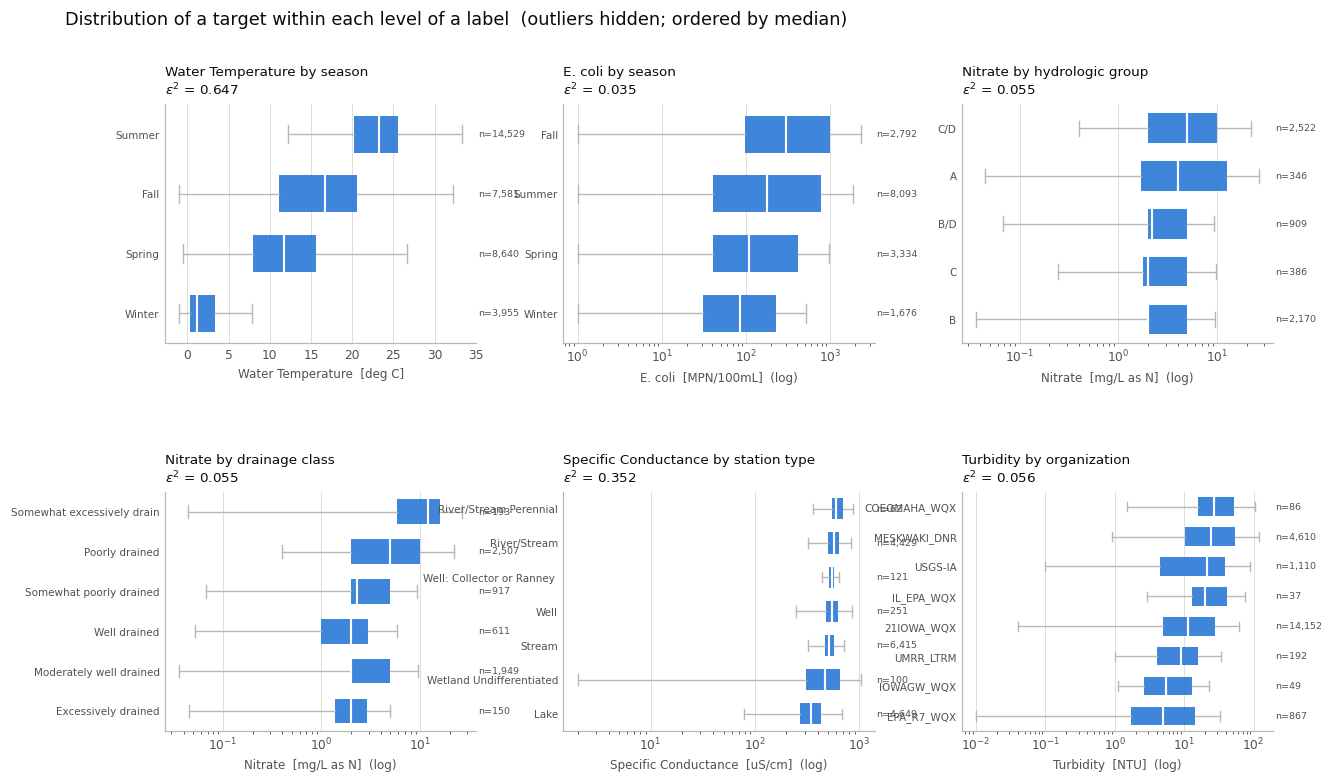

In [20]:
SHOW_CATS = [("season", "Water Temperature", False), ("season", "E. coli", True),
             ("hydrologic_group", "Nitrate", True), ("drainage_class", "Nitrate", True),
             ("MonitoringLocationTypeName", "Specific Conductance", True),
             ("OrganizationIdentifier", "Turbidity", True)]

fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.4),
                         gridspec_kw={"hspace": 0.62, "wspace": 0.28})
for ax, (ccol, tlabel, logy) in zip(axes.ravel(), SHOW_CATS):
    tcol = TARGET_COLS[tlabel]
    v = df[[tcol, ccol]].dropna()
    if logy:
        v = v[v[tcol] > 0]
    order = (v.groupby(ccol, observed=True)[tcol].median().sort_values().index)
    order = [g for g in order if (v[ccol] == g).sum() >= 30][:10]
    data = [v.loc[v[ccol] == g, tcol].to_numpy(float) for g in order]
    bp = ax.boxplot(data, vert=False, widths=0.62, patch_artist=True, showfliers=False,
                    medianprops=dict(color=SURFACE, linewidth=1.4),
                    whiskerprops=dict(color=AXISLINE, linewidth=0.9),
                    capprops=dict(color=AXISLINE, linewidth=0.9))
    for patch in bp["boxes"]:
        patch.set(facecolor=BLUE, edgecolor="none", alpha=0.9)
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels([str(g)[:26] for g in order], fontsize=6.8)
    for i, g in enumerate(order):
        ax.text(1.005, i + 1, f"n={len(data[i]):,}", transform=ax.get_yaxis_transform(),
                va="center", fontsize=6.2, color=INK_SOFT)
    if logy:
        ax.set_xscale("log")
    style_axes(ax, axis="x")
    e = cat_eff[(cat_eff["target"] == tlabel) & (cat_eff["column"] == ccol)]
    eps = e["epsilon_sq"].iloc[0] if len(e) else np.nan
    ax.set_xlabel(f"{tlabel}  [{TARGET_UNIT[tlabel]}]" + ("  (log)" if logy else ""), fontsize=7.8)
    ax.set_title(f"{tlabel} by {CAT_LABEL.get(ccol, ccol)}\n" r"$\varepsilon^2$ = " f"{eps:.3f}",
                 loc="left", fontsize=8.8)
fig.suptitle("Distribution of a target within each level of a label  (outliers hidden; "
             "ordered by median)", x=0.055, ha="left", fontsize=11.5, y=0.995)
plt.show()

## 5. Categorical ↔ categorical

The last pair type. If two labels are strongly associated with each other, then any difference
attributed to one is partly a difference in the other — which is what turns §4's group
comparisons into confounded ones. **Cramér's V** measures association between two categoricals
on a 0–1 scale; the bias-corrected form is used here because V is inflated upward when the
table has many cells relative to the sample, which is exactly the case for the
organization × county and organization × station-type tables.

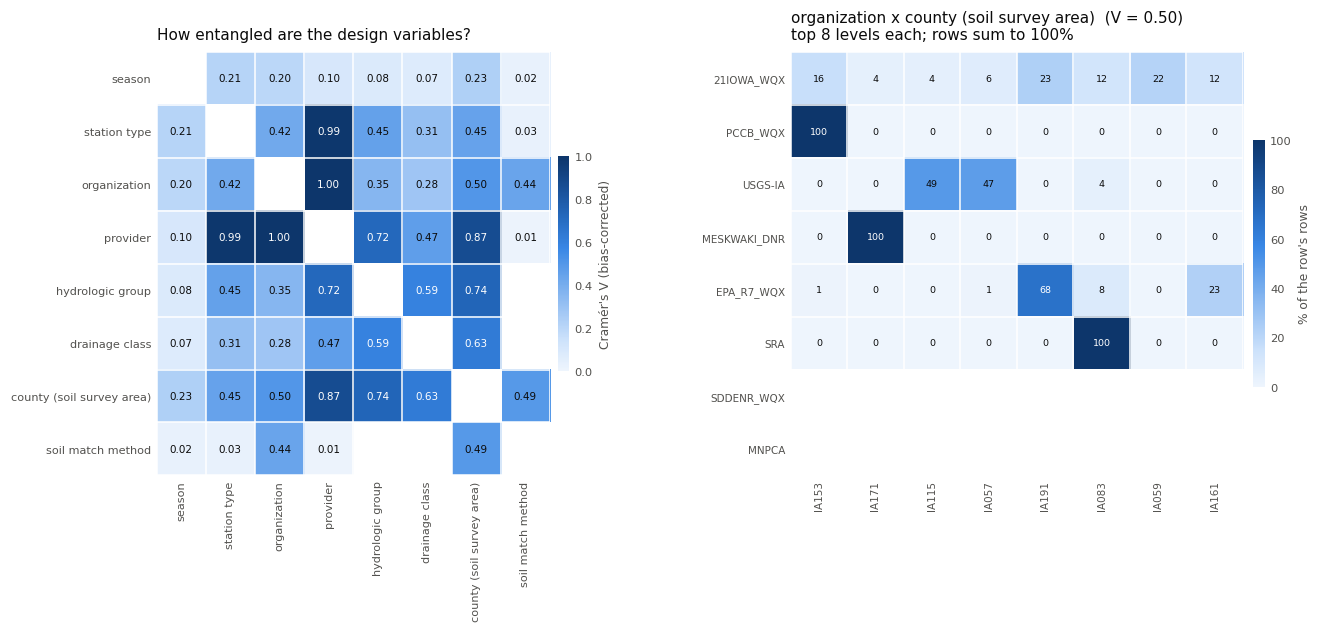

Strongest categorical associations:
                                            cramers_v
organization     provider                       1.000
station type     provider                       0.991
provider         county (soil survey area)      0.870
hydrologic group county (soil survey area)      0.736
provider         hydrologic group               0.719
drainage class   county (soil survey area)      0.628
hydrologic group drainage class                 0.593
organization     county (soil survey area)      0.502

levels per variable: season 4, station type 15, organization 21, provider 2, hydrologic group 7, drainage class 7, county (soil survey area) 99, soil match method 2


In [21]:
def cramers_v(a, b):
    """Bias-corrected Cramer's V between two categorical Series (Bergsma 2013)."""
    ct = pd.crosstab(a, b)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2 = stats.chi2_contingency(ct.to_numpy(), correction=False).statistic
    n = ct.to_numpy().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2c = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / denom)) if denom > 0 else np.nan


CAT_PAIR_COLS = ["season", "MonitoringLocationTypeName", "OrganizationIdentifier",
                 "ProviderName", "hydrologic_group", "drainage_class", "survey_area",
                 "soil_match_method"]
CAT_PAIR_LABEL = {**CAT_LABEL, "survey_area": "county (soil survey area)"}

cv = pd.DataFrame(np.nan, index=[CAT_PAIR_LABEL.get(c, c) for c in CAT_PAIR_COLS],
                  columns=[CAT_PAIR_LABEL.get(c, c) for c in CAT_PAIR_COLS])
for i, a in enumerate(CAT_PAIR_COLS):
    for j, b in enumerate(CAT_PAIR_COLS):
        if j < i:
            continue
        v = df[[a, b]].dropna()
        val = 1.0 if i == j else cramers_v(v[a], v[b])
        cv.iat[i, j] = cv.iat[j, i] = val
cv.to_csv(OUT_DIR / "bv_categorical_association.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0),
                         gridspec_kw={"wspace": 0.5, "width_ratios": [1, 1.15]})

ax = axes[0]
im = heatmap(cv, ax, cmap=SEQUENTIAL, vmin=0, vmax=1, annot_at=0.0, fmt="{:.2f}",
             fontsize=7.4, mask_diagonal=True, light_text_above=0.55)
add_colorbar(fig, im, ax, "Cramér's V (bias-corrected)")
ax.set_title("How entangled are the design variables?", loc="left", pad=8)

off = cv.where(np.triu(np.ones(cv.shape, dtype=bool), k=1)).stack()

# Show the strongest association that involves the organization, since §4 found organization
# to be the largest single "explanation" of several targets. A two-level partner (provider)
# makes a degenerate picture, so the partner must have at least four levels.
inv = {CAT_PAIR_LABEL.get(c, c): c for c in CAT_PAIR_COLS}
nlev = {lab: df[col].nunique() for lab, col in inv.items()}
cand = off[[(a, b) for a, b in off.index
            if "organization" in (a, b) and min(nlev[a], nlev[b]) >= 4]]
a_lab, b_lab = cand.idxmax()
a_col, b_col = inv[a_lab], inv[b_lab]
ct = pd.crosstab(df[a_col], df[b_col])
ct = ct.loc[ct.sum(axis=1).nlargest(8).index, ct.sum(axis=0).nlargest(8).index]
share = 100 * ct.div(ct.sum(axis=1), axis=0)

ax = axes[1]
im = heatmap(share, ax, cmap=SEQUENTIAL, vmin=0, vmax=100, annot_at=0.0, fmt="{:.0f}",
             fontsize=6.8, light_text_above=0.55)
add_colorbar(fig, im, ax, "% of the row's rows")
ax.set_title(f"{a_lab} x {b_lab}  (V = {cand.max():.2f})\n"
             "top 8 levels each; rows sum to 100%", loc="left", pad=8)
plt.show()

print("Strongest categorical associations:")
print(off.sort_values(ascending=False).head(8).rename("cramers_v").to_frame()
      .to_string(float_format=lambda v: f"{v:.3f}"))
print("\nlevels per variable:", ", ".join(f"{k} {v}" for k, v in nlev.items()))

## 6. Presence ↔ value — is missingness informative?

A variable that is absent is still one half of a pair. Two questions follow, and both bear
directly on how the models are trained:

1. **Is a target observed at random?** If the decision to measure nitrate depends on the month,
   the year or the organization, then the rows a nitrate model trains on are not a sample of
   Iowa's water — they are a sample of Iowa's *monitoring programmes*.
2. **Do rows with a missing feature have different targets?** The fitted pipelines median-impute
   internally, which is only harmless if missingness is unrelated to the response. The
   univariate notebook found `streamflow_discharge_cfs` 50.0% present and `ksat_mean` /
   `awc_mean` ~63% present — enough rows for the answer to matter.

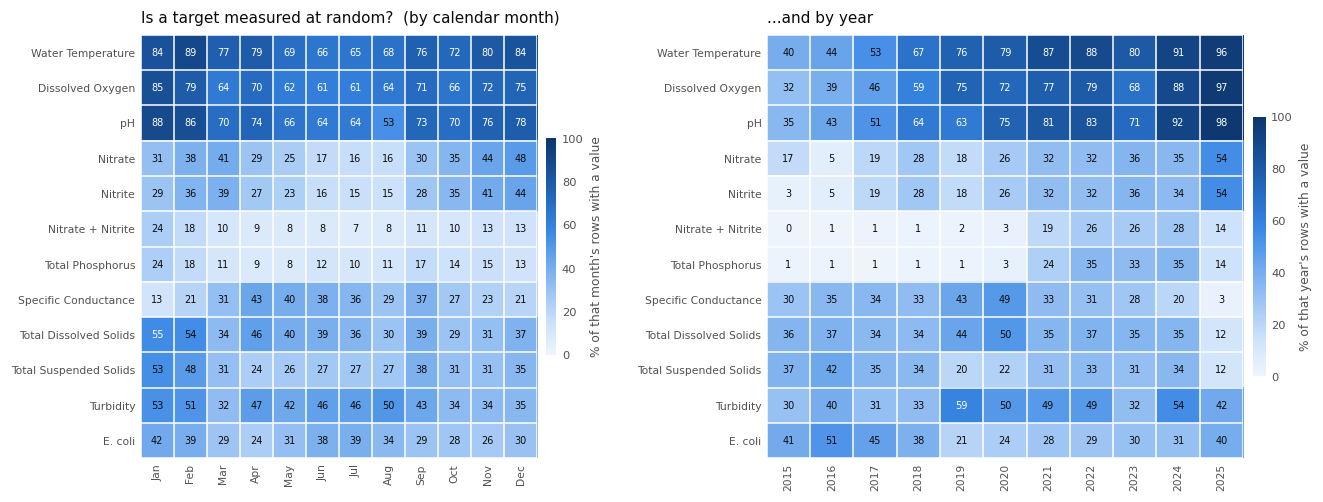

                        month_min_pct  month_max_pct  month_range  year_min_pct  year_max_pct  year_range
Dissolved Oxygen                 61.1           84.8         23.6          31.6          96.9        65.3
pH                               52.9           88.2         35.4          34.6          97.8        63.2
Water Temperature                65.4           89.1         23.6          39.6          95.6          56
Nitrite                          14.8           44.1         29.3           2.7          54.2        51.5
Nitrate                          15.8             48         32.3           4.9          54.2        49.3
Specific Conductance             12.6           43.2         30.5           2.5          48.8        46.3
Total Dissolved Solids           29.3           55.3           26            12          49.7        37.7
Total Phosphorus                  8.3           24.1         15.8           0.8          35.2        34.4
Total Suspended Solids           24.5         

In [22]:
obs_rate = pd.DataFrame({
    tlabel: df.groupby("obs_month", observed=True)[tcol].apply(lambda s: 100 * s.notna().mean())
    for tlabel, tcol in TARGET_COLS.items()}).T
obs_rate.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:obs_rate.shape[1]]
obs_year_rate = pd.DataFrame({
    tlabel: df.groupby("obs_year", observed=True)[tcol].apply(lambda s: 100 * s.notna().mean())
    for tlabel, tcol in TARGET_COLS.items()}).T
obs_rate.to_csv(OUT_DIR / "bv_observation_rate_by_month.csv")
obs_year_rate.to_csv(OUT_DIR / "bv_observation_rate_by_year.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0),
                         gridspec_kw={"wspace": 0.46, "width_ratios": [1, 1.2]})

ax = axes[0]
im = heatmap(obs_rate, ax, cmap=SEQUENTIAL, vmin=0, vmax=100, annot_at=0.0, fmt="{:.0f}",
             fontsize=7.0, light_text_above=0.55)
add_colorbar(fig, im, ax, "% of that month's rows with a value")
ax.set_title("Is a target measured at random?  (by calendar month)", loc="left", pad=8)

ax = axes[1]
im = heatmap(obs_year_rate, ax, cmap=SEQUENTIAL, vmin=0, vmax=100, annot_at=0.0, fmt="{:.0f}",
             fontsize=7.0, light_text_above=0.55)
add_colorbar(fig, im, ax, "% of that year's rows with a value")
ax.set_title("...and by year", loc="left", pad=8)
plt.show()

rng_tbl = pd.DataFrame({
    "month_min_pct": obs_rate.min(axis=1), "month_max_pct": obs_rate.max(axis=1),
    "month_range": obs_rate.max(axis=1) - obs_rate.min(axis=1),
    "year_min_pct": obs_year_rate.min(axis=1), "year_max_pct": obs_year_rate.max(axis=1),
    "year_range": obs_year_rate.max(axis=1) - obs_year_rate.min(axis=1),
}).sort_values("year_range", ascending=False)
print(rng_tbl.round(1).to_string())

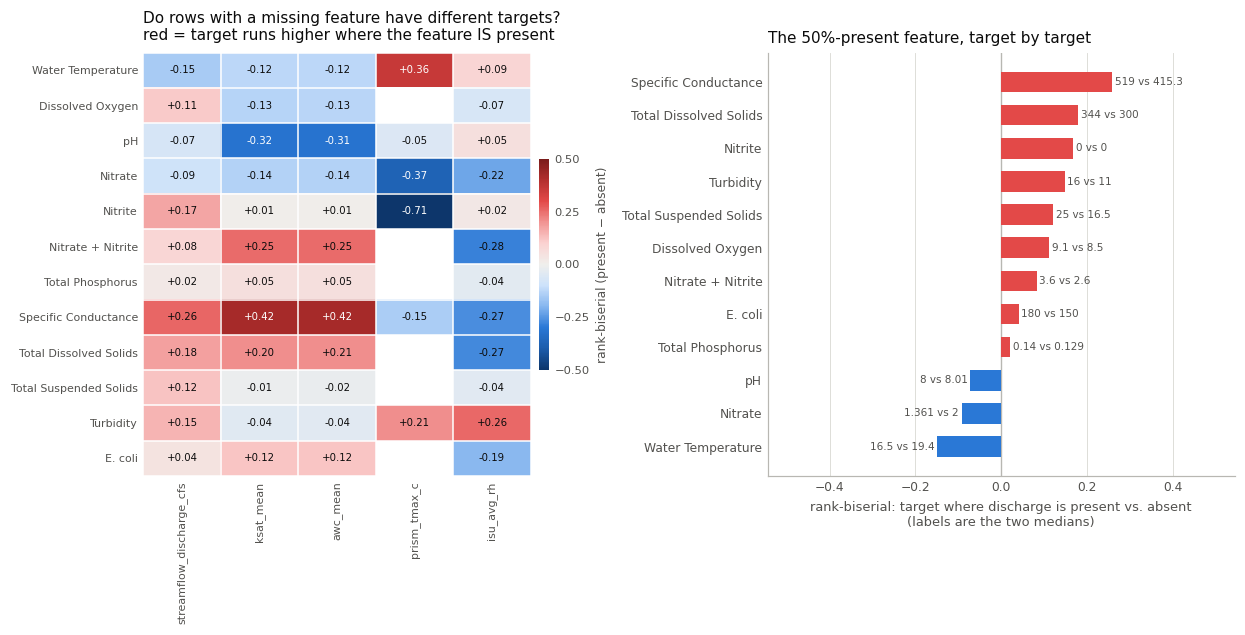

     feature                 target  median_when_present  median_when_absent  rank_biserial  n_feature_present  n_feature_absent
prism_tmax_c                Nitrite                    0             0.01242        -0.7051              11485               126
   ksat_mean   Specific Conductance                  525                 390         0.4189              10206              5861
    awc_mean   Specific Conductance                  525               390.1         0.4186              10205              5862
prism_tmax_c                Nitrate                    2               3.596        -0.3712              12214               134
prism_tmax_c      Water Temperature                18.17                 8.5         0.3592              33932               773
   ksat_mean                     pH                    8                 8.2        -0.3154              17218             15135
    awc_mean                     pH                    8                 8.2        -0.3135      

In [23]:
# Does a target look different on the rows where a feature is missing?
# Rank-biserial correlation from Mann-Whitney U: +1 = every present-row value exceeds every
# absent-row value, 0 = the two distributions are interchangeable.
GAPPY = ["streamflow_discharge_cfs", "ksat_mean", "awc_mean", "prism_tmax_c", "isu_avg_rh"]

miss_rows = []
for fcol in GAPPY:
    present = bv[fcol].notna()
    for tlabel, tcol in TARGET_COLS.items():
        a = bv.loc[present, tcol].dropna().to_numpy(float)
        b = bv.loc[~present, tcol].dropna().to_numpy(float)
        if len(a) < 100 or len(b) < 100:
            continue
        u = stats.mannwhitneyu(a, b, alternative="two-sided")
        rb = 2 * u.statistic / (len(a) * len(b)) - 1
        miss_rows.append({"feature": fcol, "target": tlabel,
                          "n_feature_present": len(a), "n_feature_absent": len(b),
                          "median_when_present": np.median(a), "median_when_absent": np.median(b),
                          "rank_biserial": rb, "p": u.pvalue,
                          "unit": TARGET_UNIT[tlabel]})
missing_bias = pd.DataFrame(miss_rows)
missing_bias.to_csv(OUT_DIR / "bv_missingness_vs_target.csv", index=False)

piv = missing_bias.pivot(index="target", columns="feature", values="rank_biserial")
piv = piv.reindex(index=list(TARGET_COLS))[GAPPY]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0),
                         gridspec_kw={"wspace": 0.5, "width_ratios": [1, 1.15]})
ax = axes[0]
im = heatmap(piv, ax, vmin=-0.5, vmax=0.5, annot_at=0.0, fmt="{:+.2f}", fontsize=7.2,
             light_text_above=0.62)
add_colorbar(fig, im, ax, "rank-biserial (present − absent)", ticks=[-0.5, -0.25, 0, 0.25, 0.5])
ax.set_title("Do rows with a missing feature have different targets?\n"
             "red = target runs higher where the feature IS present", loc="left", pad=8)

ax = axes[1]
sub = missing_bias[missing_bias["feature"] == "streamflow_discharge_cfs"].copy()
sub = sub.sort_values("rank_biserial")
ax.barh(sub["target"], sub["rank_biserial"], height=0.62, zorder=3,
        color=[RED if v > 0 else BLUE for v in sub["rank_biserial"]])
for i, r in enumerate(sub.itertuples()):
    ax.text(r.rank_biserial + (0.006 if r.rank_biserial >= 0 else -0.006), i,
            f"{r.median_when_present:,.4g} vs {r.median_when_absent:,.4g}",
            va="center", ha="left" if r.rank_biserial >= 0 else "right", fontsize=6.8,
            color=INK_SOFT)
ax.axvline(0, color=AXISLINE, linewidth=0.9, zorder=2)
style_axes(ax, axis="x")
m = sub["rank_biserial"].abs().max()
ax.set_xlim(-m * 2.1, m * 2.1)
ax.set_xlabel("rank-biserial: target where discharge is present vs. absent\n"
              "(labels are the two medians)")
ax.set_title("The 50%-present feature, target by target", loc="left")
plt.show()

print(missing_bias.reindex(missing_bias["rank_biserial"].abs().sort_values(ascending=False).index)
      .head(10)[["feature", "target", "median_when_present", "median_when_absent",
                 "rank_biserial", "n_feature_present", "n_feature_absent"]]
      .to_string(index=False, float_format=lambda v: f"{v:,.4g}"))

## 7. A variable and its own past

A variable paired with a time-shifted copy of itself is a bivariate relationship — the lag
scatterplot is the oldest one in time-series analysis — and it answers a question that no
target × feature correlation can: **how much of a measurement is predictable from the same
site's previous measurement?**

Every pair of visits to the same station gives one point: the value at the earlier visit, the
value at the later one, and the gap between them. Correlating those pairs within bins of the
gap traces out how fast a site's chemistry forgets its own state.

Two curves are drawn. The raw one is contaminated by season — two samples 365 days apart are
alike partly because both are in July — so a second curve repeats the calculation on
**seasonal anomalies**: the value's normal score minus what two harmonics of day-of-year
predict for that date. The gap between the curves is how much of the apparent persistence is
just the calendar.

In [24]:
def normal_scores(v):
    return stats.norm.ppf((stats.rankdata(v) - 0.5) / len(v))


def deseasonalise(z, doy):
    """Residual of a normal-scored series after two day-of-year harmonics."""
    w = 2 * np.pi * doy / 365.25
    Z = np.column_stack([np.ones_like(w), np.sin(w), np.cos(w), np.sin(2 * w), np.cos(2 * w)])
    beta, *_ = np.linalg.lstsq(Z, z, rcond=None)
    return z - Z @ beta


LAG_EDGES = np.array([0, 3, 7, 14, 30, 60, 120, 240, 400, 750, 1500, 4000])
MAX_PER_STATION = 120          # cap so one 2,878-visit station cannot dominate
MAX_PAIRS_PER_STATION = 600
rng = np.random.default_rng(11)

lag_rows, lag_pairs_kept = [], {}
for tlabel, tcol in TARGET_COLS.items():
    v = bv[[ID_COL, DATE_COL, tcol]].dropna().sort_values([ID_COL, DATE_COL])
    if len(v) < 500:
        continue
    z = normal_scores(v[tcol].to_numpy(float))
    doy = v[DATE_COL].dt.dayofyear.to_numpy(float)
    a = deseasonalise(z, doy)
    day = (v[DATE_COL].to_numpy("datetime64[D]").astype("int64")).astype(float)
    codes, uniq = pd.factorize(v[ID_COL].to_numpy())

    order = np.argsort(codes, kind="stable")
    z, a, day, codes = z[order], a[order], day[order], codes[order]
    starts = np.searchsorted(codes, np.arange(len(uniq)))
    ends = np.searchsorted(codes, np.arange(len(uniq)), side="right")

    A, B, AA, BB, GAP = [], [], [], [], []
    for s, e in zip(starts, ends):
        idx = np.arange(s, e)
        if len(idx) < 2:
            continue
        if len(idx) > MAX_PER_STATION:
            idx = np.sort(rng.choice(idx, MAX_PER_STATION, replace=False))
        i, j = np.triu_indices(len(idx), k=1)
        if len(i) > MAX_PAIRS_PER_STATION:
            pick = rng.choice(len(i), MAX_PAIRS_PER_STATION, replace=False)
            i, j = i[pick], j[pick]
        A.append(z[idx[i]]); B.append(z[idx[j]])
        AA.append(a[idx[i]]); BB.append(a[idx[j]])
        GAP.append(np.abs(day[idx[j]] - day[idx[i]]))
    if not A:
        continue
    A, B = np.concatenate(A), np.concatenate(B)
    AA, BB = np.concatenate(AA), np.concatenate(BB)
    GAP = np.concatenate(GAP)
    lag_pairs_kept[tlabel] = len(GAP)

    b = np.clip(np.searchsorted(LAG_EDGES, GAP, side="right") - 1, 0, len(LAG_EDGES) - 2)
    for k in range(len(LAG_EDGES) - 1):
        m = b == k
        if m.sum() < 150:
            continue
        # Symmetrised: a pair is unordered, so both assignments enter the correlation.
        raw = np.corrcoef(np.r_[A[m], B[m]], np.r_[B[m], A[m]])[0, 1]
        adj = np.corrcoef(np.r_[AA[m], BB[m]], np.r_[BB[m], AA[m]])[0, 1]
        lag_rows.append({"target": tlabel, "lag_lo": LAG_EDGES[k], "lag_hi": LAG_EDGES[k + 1],
                         "lag_mid": float(np.median(GAP[m])), "n_pairs": int(m.sum()),
                         "corr_raw": raw, "corr_deseasonalised": adj})
lagcorr = pd.DataFrame(lag_rows)
lagcorr.to_csv(OUT_DIR / "bv_temporal_autocorrelation.csv", index=False)
print(f"within-station visit pairs used: "
      f"{', '.join(f'{k} {v:,}' for k, v in list(lag_pairs_kept.items())[:4])} ...")
print(f"total {sum(lag_pairs_kept.values()):,} pairs across {len(lag_pairs_kept)} targets")

within-station visit pairs used: Water Temperature 192,117, Dissolved Oxygen 184,279, pH 192,888, Nitrate 55,041 ...
total 1,312,250 pairs across 12 targets


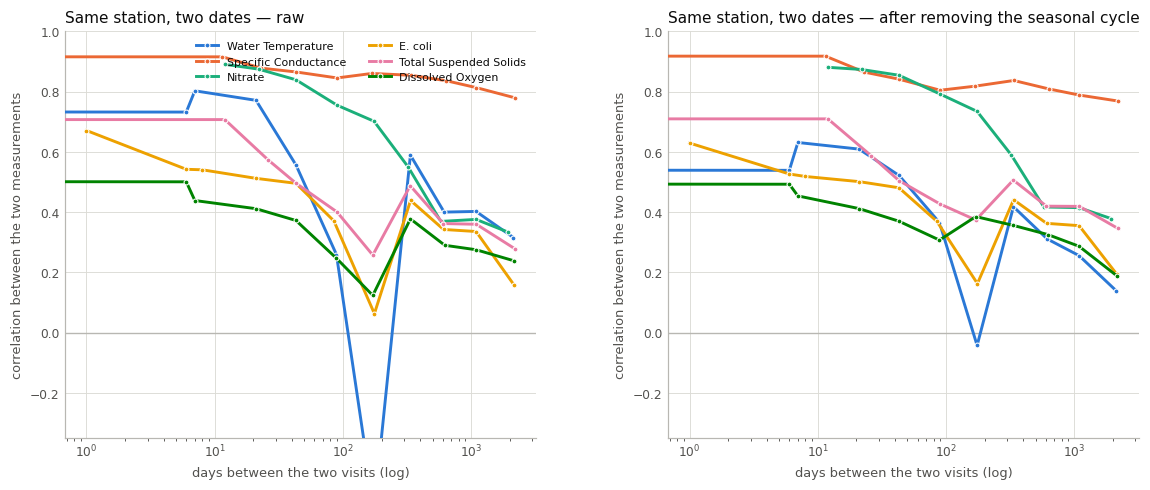

Correlation between two visits to the same station, by gap (deseasonalised):
lag_lo                  0     3     7     14    30    60    120   240   400   750   1500
target                                                                                  
Dissolved Oxygen        0.74  0.49  0.45  0.41  0.37  0.31  0.39  0.36  0.33  0.29  0.19
E. coli                 0.63  0.53  0.52   0.5  0.48  0.37  0.16  0.44  0.36  0.35  0.19
Nitrate                  NaN   NaN  0.88  0.87  0.85  0.79  0.73  0.59  0.42  0.41  0.38
Nitrate + Nitrite        NaN   NaN   NaN   0.7  0.67   0.4  0.16  0.36  0.36  0.39  0.52
Nitrite                  NaN   NaN   0.6  0.52  0.54   0.5  0.51   0.5   0.5  0.46  0.42
Specific Conductance    0.98   NaN  0.92  0.86  0.84   0.8  0.82  0.84  0.81  0.79  0.77
Total Dissolved Solids   0.9   NaN  0.89  0.86  0.85  0.82  0.73  0.82  0.79  0.76  0.75
Total Phosphorus         NaN   NaN   NaN  0.58  0.62  0.42  0.29  0.51  0.44  0.36  0.58
Total Suspended Solids  0.69   Na

In [25]:
SHOW_T = ["Water Temperature", "Specific Conductance", "Nitrate", "E. coli",
          "Total Suspended Solids", "Dissolved Oxygen"]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), gridspec_kw={"wspace": 0.28})

for ax, col, name in zip(axes, ["corr_raw", "corr_deseasonalised"],
                         ["raw", "after removing the seasonal cycle"]):
    for c, t in zip(SERIES, SHOW_T):
        s = lagcorr[lagcorr["target"] == t]
        if s.empty:
            continue
        ax.plot(s["lag_mid"], s[col], color=c, linewidth=1.9, marker="o", markersize=3.2,
                markeredgecolor=SURFACE, markeredgewidth=0.7, zorder=3, label=t)
    ax.axhline(0, color=AXISLINE, linewidth=0.9, zorder=2)
    ax.set_xscale("log")
    style_axes(ax, axis="both")
    ax.set_ylim(-0.35, 1.0)
    ax.set_xlabel("days between the two visits (log)")
    ax.set_ylabel("correlation between the two measurements")
    ax.set_title(f"Same station, two dates — {name}", loc="left")
axes[0].legend(fontsize=7.2, loc="upper right", ncol=2)
plt.show()

wide = lagcorr.pivot_table(index="target", columns="lag_lo",
                           values=["corr_raw", "corr_deseasonalised"])
print("Correlation between two visits to the same station, by gap (deseasonalised):")
print(wide["corr_deseasonalised"].round(2).to_string())

### 7.1 The persistence baseline

If a site's next measurement is largely its previous one, then "predict the previous value"
is a model — a trivial one, with no features at all — and it is the baseline any feature-based
model has to beat. The comparison below uses each target's consecutive visit pairs: predict
visit *t* with the value at visit *t−1*, and score it with the same R² the training notebooks
report.

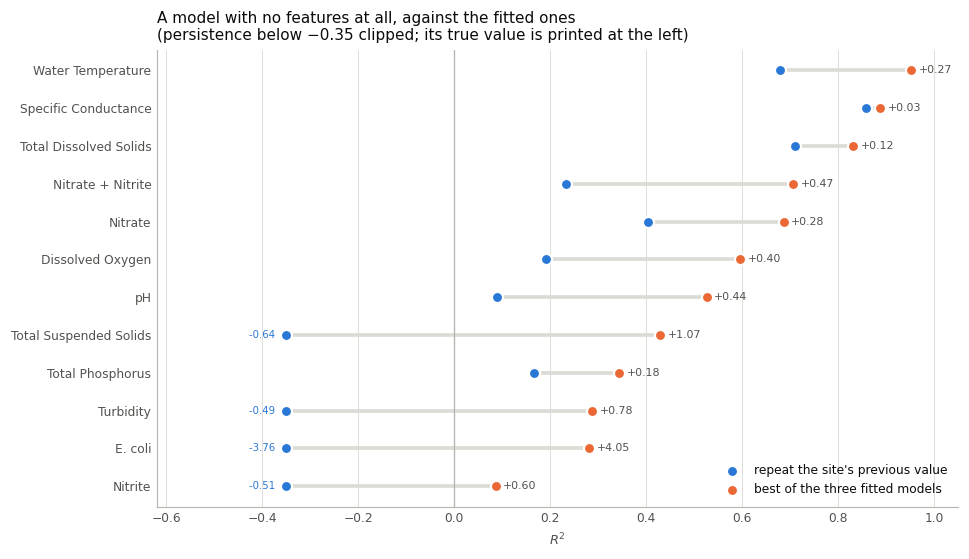

                        n_pairs  median_gap_days  persistence_r2  persistence_rho  rf_r2  best_model_r2  model_minus_persistence
target                                                                                                                          
Specific Conductance      15584                1           0.857            0.909  0.886          0.888                     0.03
Total Dissolved Solids    17429               29           0.709            0.871  0.824          0.831                    0.122
Total Phosphorus           5433               33           0.167            0.623   0.33          0.344                    0.176
Water Temperature         33706               20           0.679            0.822  0.952          0.952                    0.274
Nitrate                   12070               15           0.403            0.751  0.674          0.686                    0.283
Dissolved Oxygen          30916               21           0.192            0.595  0.596         

In [26]:
metrics = pd.read_csv(METRICS_PATH)
rf_r2 = metrics[metrics["model"] == "Random Forest"].set_index("target")["r2"]
best_r2 = metrics.groupby("target")["r2"].max()

pers_rows = []
for tlabel, tcol in TARGET_COLS.items():
    v = bv[[ID_COL, DATE_COL, tcol]].dropna().sort_values([ID_COL, DATE_COL])
    g = v.groupby(ID_COL, observed=True)
    prev = g[tcol].shift(1)
    gap = g[DATE_COL].diff().dt.days
    m = prev.notna()
    if m.sum() < 200:
        continue
    y, yhat = v.loc[m, tcol].to_numpy(float), prev[m].to_numpy(float)
    ss_res = float(((y - yhat) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    pers_rows.append({
        "target": tlabel, "n_pairs": int(m.sum()), "median_gap_days": float(gap[m].median()),
        "persistence_r2": 1 - ss_res / ss_tot,
        "persistence_rho": stats.spearmanr(y, yhat).statistic,
        "rf_r2": float(rf_r2.get(tlabel, np.nan)),
        "best_model_r2": float(best_r2.get(tlabel, np.nan)),
    })
persist = pd.DataFrame(pers_rows).set_index("target")
persist["model_minus_persistence"] = persist["best_model_r2"] - persist["persistence_r2"]
persist.to_csv(OUT_DIR / "bv_persistence_baseline.csv")

o = persist.sort_values("best_model_r2")
fig, ax = plt.subplots(figsize=(9.4, 5.4))
y = np.arange(len(o))
ax.hlines(y, o["persistence_r2"].clip(lower=-0.35), o["best_model_r2"], color=GRIDLINE,
          linewidth=2.4, zorder=2)
ax.scatter(o["persistence_r2"].clip(lower=-0.35), y, s=52, color=BLUE, zorder=3,
           edgecolor=SURFACE, linewidth=1.4, label="repeat the site's previous value")
ax.scatter(o["best_model_r2"], y, s=52, color=ORANGE, zorder=3, edgecolor=SURFACE,
           linewidth=1.4, label="best of the three fitted models")
for i, r in enumerate(o.itertuples()):
    ax.text(max(r.persistence_r2, r.best_model_r2) + 0.016, i,
            f"+{r.best_model_r2 - r.persistence_r2:.2f}", va="center", fontsize=7.2,
            color=INK_SOFT)
    if r.persistence_r2 < -0.35:                       # say what the clipped value really is
        ax.text(-0.36, i, f"{r.persistence_r2:.2f}  ", va="center", ha="right", fontsize=6.6,
                color=BLUE)
ax.axvline(0, color=AXISLINE, linewidth=0.9, zorder=2)
ax.set_yticks(y); ax.set_yticklabels(o.index, fontsize=8)
style_axes(ax, axis="x")
ax.set_xlim(-0.62, 1.05)
ax.set_xlabel(r"$R^2$")
ax.set_title("A model with no features at all, against the fitted ones\n"
             "(persistence below −0.35 clipped; its true value is printed at the left)",
             loc="left")
ax.legend(fontsize=8, loc="lower right")
plt.show()

print(persist[["n_pairs", "median_gap_days", "persistence_r2", "persistence_rho",
               "rf_r2", "best_model_r2", "model_minus_persistence"]]
      .sort_values("model_minus_persistence").round(3).to_string())

## 8. A variable and its neighbour

The spatial counterpart of §7, and the one that decides whether the dashboard's map is
meaningful. `app.py` fills the space between stations with `scipy.griddata` cubic
interpolation, which assumes that a value at an unsampled point can be inferred from the values
around it. That assumption is testable: **how alike are two stations' measurements of the same
thing on the same day, as a function of how far apart they are?**

Restricting to same-day pairs removes season, weather and year as confounders without any
modelling — both members of the pair were measured under the same conditions, so what remains
is spatial structure. If the correlation decays to zero within a few tens of kilometres while
the typical gap between stations is larger than that, the interpolated surface between stations
is drawing a field that the data does not support.

In [27]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


DIST_EDGES = np.array([0, 5, 10, 20, 40, 80, 160, 320, 640])
MAX_PAIRS_PER_DAY = 300
rng = np.random.default_rng(23)

spa_rows, colocated = [], {}
for tlabel, tcol in TARGET_COLS.items():
    v = df[[ID_COL, DATE_COL, "LatitudeMeasure", "LongitudeMeasure", tcol]].dropna()
    if len(v) < 800:
        continue
    v = v.assign(day=v[DATE_COL].dt.normalize())
    z = normal_scores(v[tcol].to_numpy(float))
    lat = v["LatitudeMeasure"].to_numpy(float)
    lon = v["LongitudeMeasure"].to_numpy(float)
    sid = pd.factorize(v[ID_COL].to_numpy())[0]
    dcode = pd.factorize(v["day"].to_numpy())[0]

    order = np.argsort(dcode, kind="stable")
    z, lat, lon, sid, dcode = z[order], lat[order], lon[order], sid[order], dcode[order]
    nd = dcode.max() + 1
    starts = np.searchsorted(dcode, np.arange(nd))
    ends = np.searchsorted(dcode, np.arange(nd), side="right")

    A, B, D, SAME = [], [], [], []
    for s, e in zip(starts, ends):
        k = e - s
        if k < 2:
            continue
        idx = np.arange(s, e)
        i, j = np.triu_indices(k, k=1)
        if len(i) > MAX_PAIRS_PER_DAY:
            pick = rng.choice(len(i), MAX_PAIRS_PER_DAY, replace=False)
            i, j = i[pick], j[pick]
        ii, jj = idx[i], idx[j]
        A.append(z[ii]); B.append(z[jj])
        D.append(haversine_km(lat[ii], lon[ii], lat[jj], lon[jj]))
        SAME.append(sid[ii] == sid[jj])
    if not A:
        continue
    A, B = np.concatenate(A), np.concatenate(B)
    D, SAME = np.concatenate(D), np.concatenate(SAME)

    # Same station, same day, different times: the zero-distance anchor.
    if SAME.sum() >= 100:
        colocated[tlabel] = (float(np.corrcoef(np.r_[A[SAME], B[SAME]],
                                               np.r_[B[SAME], A[SAME]])[0, 1]), int(SAME.sum()))
    A, B, D = A[~SAME], B[~SAME], D[~SAME]
    b = np.clip(np.searchsorted(DIST_EDGES, D, side="right") - 1, 0, len(DIST_EDGES) - 2)
    for k in range(len(DIST_EDGES) - 1):
        m = b == k
        if m.sum() < 150:
            continue
        spa_rows.append({"target": tlabel, "dist_lo": DIST_EDGES[k], "dist_hi": DIST_EDGES[k + 1],
                         "dist_mid": float(np.median(D[m])), "n_pairs": int(m.sum()),
                         "corr": float(np.corrcoef(np.r_[A[m], B[m]], np.r_[B[m], A[m]])[0, 1])})
spatial = pd.DataFrame(spa_rows)
spatial.to_csv(OUT_DIR / "bv_spatial_autocorrelation.csv", index=False)
print(f"{spatial['n_pairs'].sum():,} same-day station pairs across "
      f"{spatial['target'].nunique()} targets")
print("\nSame station, same day, different times (the d -> 0 anchor):")
for t, (c, n) in colocated.items():
    print(f"  {t:<24s} r = {c:+.3f}  on {n:,} pairs")

1,270,214 same-day station pairs across 12 targets

Same station, same day, different times (the d -> 0 anchor):
  Water Temperature        r = +0.977  on 3,245 pairs
  Dissolved Oxygen         r = +0.960  on 2,628 pairs
  pH                       r = +0.941  on 2,589 pairs
  Nitrate                  r = +0.759  on 140 pairs
  Specific Conductance     r = +0.973  on 4,537 pairs
  Total Dissolved Solids   r = +0.943  on 2,941 pairs
  Total Suspended Solids   r = +0.646  on 354 pairs
  Turbidity                r = +0.936  on 3,092 pairs
  E. coli                  r = +0.808  on 110 pairs


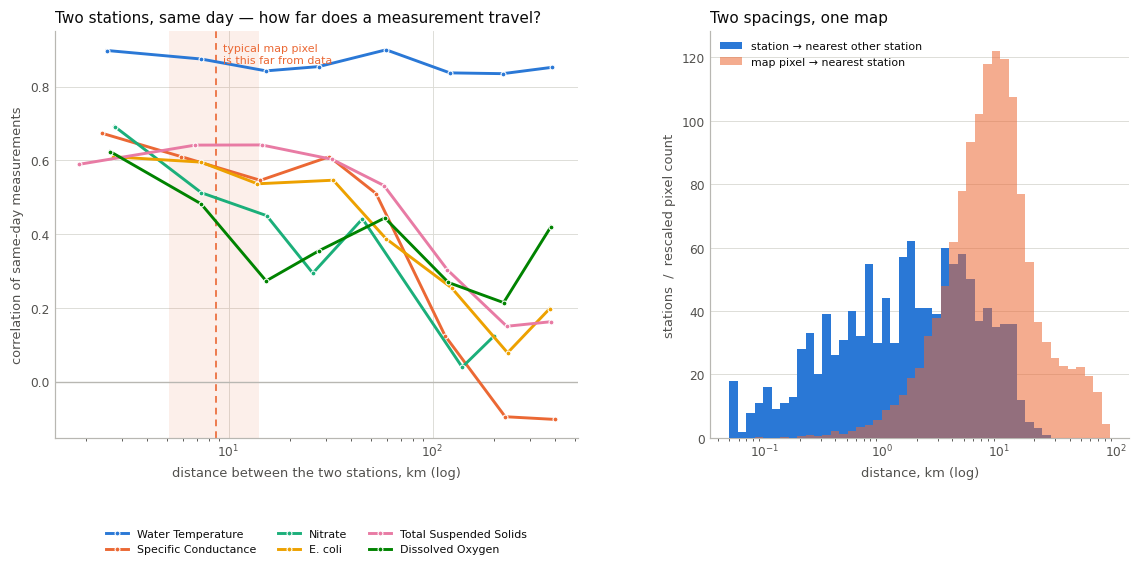

                        corr_at_0_5km  n_pairs_0_5km  corr_20_40km  corr_80_160km
target                                                                           
Water Temperature               0.898          11261         0.854          0.837
Total Dissolved Solids          0.775           5805         0.693          0.318
Nitrate                         0.692           7364         0.294          0.039
Specific Conductance            0.673           4939          0.61          0.124
Dissolved Oxygen                0.624          10758         0.354          0.269
Nitrate + Nitrite               0.615           1024         0.594          0.319
E. coli                          0.61           7857         0.546          0.254
pH                              0.606          10984         0.342          0.151
Total Suspended Solids          0.589           4227         0.603          0.304
Turbidity                       0.558           6032         0.556          0.271
Total Phosphorus

In [28]:
# Two different distances matter, and they are not the same number.
#   nn  — how far apart the stations are (how dense the sample is)
#   gd  — how far a point on the interpolated map is from the nearest station, which is the
#         distance the app's griddata surface is actually being asked to carry a value across.
st = df.groupby(ID_COL, observed=True)[["LatitudeMeasure", "LongitudeMeasure"]].first().dropna()
la, lo = st["LatitudeMeasure"].to_numpy(), st["LongitudeMeasure"].to_numpy()
Dm = haversine_km(la[:, None], lo[:, None], la[None, :], lo[None, :])
np.fill_diagonal(Dm, np.inf)
nn = Dm.min(axis=1)

glat = np.linspace(la.min(), la.max(), 140)
glon = np.linspace(lo.min(), lo.max(), 140)
GLAT, GLON = np.meshgrid(glat, glon, indexing="ij")
gd = np.full(GLAT.size, np.inf)
flat_lat, flat_lon = GLAT.ravel(), GLON.ravel()
for k in range(0, len(la), 200):                       # chunked to keep the matrix small
    d = haversine_km(flat_lat[:, None], flat_lon[:, None],
                     la[None, k:k + 200], lo[None, k:k + 200])
    gd = np.minimum(gd, d.min(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8),
                         gridspec_kw={"wspace": 0.28, "width_ratios": [1.25, 1]})

ax = axes[0]
for c, t in zip(SERIES, SHOW_T):
    s = spatial[spatial["target"] == t]
    if s.empty:
        continue
    ax.plot(s["dist_mid"], s["corr"], color=c, linewidth=1.9, marker="o", markersize=3.2,
            markeredgecolor=SURFACE, markeredgewidth=0.7, zorder=3, label=t)
ax.axhline(0, color=AXISLINE, linewidth=0.9, zorder=2)
ax.axvspan(np.percentile(gd, 25), np.percentile(gd, 75), color=ORANGE, alpha=0.10,
           zorder=1, linewidth=0)
ax.axvline(np.median(gd), color=ORANGE, linewidth=1.1, linestyle=(0, (4, 3)), zorder=2)
ax.text(np.median(gd), 0.97, "  typical map pixel\n  is this far from data",
        transform=ax.get_xaxis_transform(), va="top", fontsize=7.2, color=ORANGE)
ax.set_xscale("log")
style_axes(ax, axis="both")
ax.set_xlabel("distance between the two stations, km (log)")
ax.set_ylabel("correlation of same-day measurements")
ax.set_title("Two stations, same day — how far does a measurement travel?", loc="left")
ax.legend(fontsize=7.2, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)

ax = axes[1]
bins = np.logspace(np.log10(0.05), np.log10(max(nn.max(), gd.max())), 46)
ax.hist(nn, bins=bins, color=BLUE, zorder=3, label="station → nearest other station")
ax.hist(gd, bins=bins, color=ORANGE, alpha=0.55, zorder=4,
        weights=np.full(gd.size, len(nn) / gd.size), label="map pixel → nearest station")
ax.set_xscale("log")
style_axes(ax)
ax.set_xlabel("distance, km (log)")
ax.set_ylabel("stations  /  rescaled pixel count")
ax.set_title("Two spacings, one map", loc="left")
ax.legend(fontsize=7.2, loc="upper left")
plt.show()

first = spatial.sort_values("dist_mid").groupby("target", observed=True).first()
summary = pd.DataFrame({
    "corr_at_0_5km": first["corr"],
    "n_pairs_0_5km": first["n_pairs"],
    "corr_20_40km": spatial[spatial["dist_lo"] == 20].set_index("target")["corr"],
    "corr_80_160km": spatial[spatial["dist_lo"] == 80].set_index("target")["corr"],
}).sort_values("corr_at_0_5km", ascending=False)
print(summary.round(3).to_string())
print(f"\nstation spacing      : median {np.median(nn):.1f} km, "
      f"p25 {np.percentile(nn, 25):.1f}, p75 {np.percentile(nn, 75):.1f}, max {nn.max():.0f}")
print(f"map pixel -> station : median {np.median(gd):.1f} km, "
      f"p75 {np.percentile(gd, 75):.1f}, p95 {np.percentile(gd, 95):.1f}, max {gd.max():.0f}")
print(f"share of the map more than 20 km from any station: {100 * (gd > 20).mean():.0f}%   "
      f"more than 40 km: {100 * (gd > 40).mean():.0f}%")

## 9. Findings

### What a coefficient hides

- **Only 33 of the 360 target × feature pairs (9%) have a simple monotone shape** — 19 rising,
  12 falling, 2 threshold. **115 (32%) are single-peaked** (69 humps, 46 valleys), for which a
  correlation coefficient reports the average of two opposite slopes.
- **212 of 360 (59%) have no shape a single feature could be used on**: 70 flat, 102 irregular,
  and 40 where the feature is too discrete to cut into deciles at all (`isu_snow_in`,
  `isu_snowd_in`, `prism_ppt_mm` and the two `npfert__` columns — all of which the univariate
  notebook flagged as zero-dominated or coarsely levelled).
- Two pairs make the case on their own. **Water Temperature ← `doy`** has ρ = **+0.24** and a
  conditional median that runs from **1.1 °C to 24.7 °C** — 1.82 interquartile ranges, among
  the fifteen largest effects in the table. **Specific Conductance ← `LongitudeMeasure`** has
  ρ = **+0.0007** — indistinguishable from zero — and a conditional median running from
  **327 to 703 µS/cm**, 2.17 IQRs — the third-largest effect measured. Neither number is
  wrong; both are useless.
- Ranking pairs by magnitude and by correlation gives different answers: the two rankings agree
  at only ρ = **+0.56** across the 250 pairs with a usable shape.
- **`Nitrate ← pct_corn` is a cliff, not a slope.** The conditional median is **0 mg/L across
  the four lowest deciles** of corn share, **2 mg/L across the middle five**, and **10 mg/L in
  the top decile** — a five-fold jump concentrated in a single step. Reported as ρ = +0.49 it
  reads as a gradual gradient.

### Spread is a second relationship

- **126 of 292 pairs (43%) have a conditional interquartile range that varies by more than 3×**
  across the feature's range, and 21 grow monotonically with it. The extreme is
  `Nitrate ← awc_mean` at **20×**.
- This is the mechanism behind the univariate notebook's warning about squared-error loss: for
  those pairs, training is dominated by whichever end of the predictor's range is noisiest, and
  a single global RMSE averages two regimes that behave nothing alike.

### The rows are not independent, and it costs an order of magnitude

- The station-cluster design effect has a **median of 18.3 and a maximum of 165**. The median
  pair is computed on **15,850 rows worth about 1,006 independent observations**; the quartiles
  of the effective sample size are 419 / 1,006 / 2,207, and **28 pairs are worth fewer than 200**.
- The damage is concentrated exactly where the multivariate notebook found the between-station
  signal: **soil ×47.8, location ×31.0, land cover ×29.4, nutrients ×28.1, streamflow ×27.7**,
  against climate ×8.9, weather ×6.1 and temporal ×6.0. A station-constant feature contributes
  one piece of information per station, not one per visit, and the design effect measures
  exactly that.
- The sandwich estimator agrees with a 400-replicate station-cluster bootstrap to within 5% on
  three of the four pairs checked. On the fourth it is 22% *too small*, so where the two
  disagree the analytic interval is the optimistic one.
- The consequence for evidence: of 360 pairs, **324 clear p < 0.05 if rows are treated as
  independent, 247 survive the clustered standard error, 239 survive Benjamini–Hochberg, and
  only 30 have \|ρ\| ≥ 0.30.** Ten relationships are formally significant with \|ρ\| < 0.05.
- One concrete casualty: the pooled **Specific Conductance ← discharge** correlation is
  −0.171 with a cluster-bootstrap 95% interval of **[−0.299, +0.046]** — it includes zero.

### Single observations

- Rank-based coefficients are safe: one row can move Spearman's ρ by at most O(1/n) ≈ **6×10⁻⁵**
  at the median sample size. Pearson is not: 14 pairs move by more than 0.02 and 2 by more
  than 0.05.
- **Five of the six most-influential rows in the whole table are the same observation** —
  station `ERG-RC13`, the 2,420,000 MPN/100 mL *E. coli* reading the univariate notebook
  flagged. Deleting it alone takes `E. coli ← prism_ppt_mm` from r = **+0.101 to +0.205**.

### Pairs where one side is a label

- **`season` × Water Temperature is the single largest categorical effect in the table,
  ε² = 0.647** — and it is the *only* large one attached to a label that varies within a
  station (72.2% of stations are sampled in more than one season). Every other categorical here
  is 100% station-constant.
- The next-largest effects are not measurements of water: **Nitrite by organization
  ε² = 0.459**, by station type 0.454; **Total Dissolved Solids by station type 0.356**;
  **Specific Conductance by station type 0.352, by organization 0.332**. For comparison,
  Nitrite's best *feature* manages ρ² = 0.125.
- **`ProviderName` is a deterministic relabelling of `OrganizationIdentifier`** (Cramér's
  V = **1.000**): USGS-IA rows come from NWIS, all twenty other organizations from STORET. It
  carries no information the organization column does not.
- Organization is also entangled with geography — **V = 0.502 against county** — so any
  target difference "by organization" is partly a difference of place, and vice versa.

### Missingness carries signal

- **Whether a target is measured at all swings by 27–65 percentage points across years.**
  Dissolved Oxygen is present on 31.6% of rows in its worst year and 96.9% in its best; pH
  34.6 → 97.8; Nitrite 2.7 → 54.2. Month-to-month the range is 16–35 points. The rows a model
  trains on are a sample of monitoring programmes, not of Iowa's water.
- **Feature missingness is not random with respect to the target.** Where `ksat_mean` and
  `awc_mean` are missing — 37% of rows — the median Specific Conductance is **390 µS/cm**
  against **525** where they are present (rank-biserial **+0.42**). `streamflow_discharge_cfs`,
  missing on 50% of rows, shows the same sign at +0.26 (519 vs 415 µS/cm). The fitted
  pipelines median-impute all three, which replaces a systematically different subpopulation
  with the middle of the other one.

### A variable and its own past

- With the seasonal cycle removed, **Specific Conductance and Total Dissolved Solids barely
  decay at all**: two visits to the same station 2–4 years apart still correlate at **0.77 and
  0.75**. Nitrate decays from 0.88 at a week to 0.38 beyond two years; Water Temperature from
  0.63 to **0.14**; Dissolved Oxygen from 0.45 to 0.19.
- That split *is* the between/within distinction the multivariate notebook measured, seen in
  the time domain: a target whose deseasonalised autocorrelation stays high at multi-year lags
  is a target that is mostly a property of the site.
- Every target dips at a **120–240 day** separation and recovers at 240–400 days. Two samples
  half a year apart sit on opposite sides of the seasonal cycle, and the harmonic fit removes
  only the *average* cycle, not each station's own amplitude — so what is left is
  anti-correlated at half-year lags and correlated at full-year ones.
- **The persistence baseline — "predict this site's next value with its last value", no
  features at all — reaches R² = 0.857 for Specific Conductance against the best fitted model's
  0.888, and 0.709 for Total Dissolved Solids against 0.831.** Conductance's consecutive visits
  have a median gap of 1 day, which flatters it; Total Dissolved Solids' median gap is 29 days,
  which does not. Water Temperature is the clearest genuine win (0.679 → 0.952), and for the
  heavy-tailed targets persistence is worse than the mean (E. coli −3.76, TSS −0.64).

### A variable and its neighbour

- **Repeat measurement is not the problem.** Two samples at the same station on the same day at
  different times correlate at **0.98 (Water Temperature), 0.97 (Specific Conductance), 0.96
  (Dissolved Oxygen), 0.94 (pH, TDS, Turbidity)**. Whatever limits these models, it is not
  instrument noise.
- Spatial decay separates the targets sharply. **Water Temperature does not decay at all** —
  0.90 at 0–5 km and still 0.84 at 160–320 km, because it is set by regional air temperature.
  **Nitrate decays fast**: 0.69 at 0–5 km, 0.51 by 5–10 km, 0.29 at 20–40 km, 0.04 beyond
  80 km. Total Phosphorus, pH and Dissolved Oxygen behave similarly.
- **Stations are dense but the map is not.** The median station has another within **1.3 km**,
  yet the median pixel of the interpolated surface is **8.7 km** from the nearest station,
  the 95th percentile is **43 km**, and **15% of the rendered map is more than 20 km from any
  observation**.
- `Nitrite` is anomalous: its same-day between-station correlation is only 0.34 at 0–5 km and
  goes to **−0.61** at 80–160 km. A genuinely spatial variable does not do that; it is the
  signature of two reporting conventions (the univariate notebook's 84% zeros) partitioned
  across regions.

## 10. Red flags

Seven issues. Flags 1, 2 and 4 are new — they could not be seen from a univariate distribution
or from a correlation matrix. Flags 3, 5, 6 and 7 sharpen or re-measure problems the companion
notebooks raised.

| # | Red flag | Severity | Where |
|---|----------|----------|-------|
| 1 | Every sample size in the project is inflated ~18× by station clustering | **critical** | `model_metrics.csv`, training notebooks |
| 2 | A zero-feature "repeat the last measurement" baseline nearly matches the two best models | **critical** | training notebooks |
| 3 | The map interpolates far past the distance most analytes stay correlated over | **high** | `app.py` |
| 4 | Median-imputed features are missing in a target-dependent way | **high** | training notebooks, `app.py` |
| 5 | 59% of target–feature pairs carry no usable shape | **high** | `FEATURE_COLS` |
| 6 | Programme identity explains more of some targets than any feature does | medium | data |
| 7 | `ProviderName` is a duplicate of `OrganizationIdentifier` | low | data |

**1. Sample sizes are inflated by roughly an order of magnitude (critical).**
The median target × feature pair has a station-cluster design effect of **18.3**, so its 15,850
rows are worth about **1,006 independent observations**; for the soil and location blocks the
factor reaches **165**. Nothing in the project accounts for this. `model_metrics.csv` reports
`test_rows` of 932–6,941 with no interval on R², and those test rows are drawn from the same
few hundred stations — the univariate notebook found 99.1–99.7% of test rows sit at a station
also in training. An R² quoted to three decimals on ~300 effective observations is precision
theatre. **Fix:** report R² with a station-cluster bootstrap interval (resample stations, not
rows, and refit), and state the number of distinct test stations next to `test_rows` in
`model_metrics.csv`. Expect the intervals to be wide enough to make several of the
between-model comparisons meaningless.

**2. A model with no features nearly matches the two best-scoring targets (critical).**
"Predict this station's next value with its previous value" scores **R² = 0.857 for Specific
Conductance** against the best fitted model's 0.888, and **0.709 for Total Dissolved Solids**
against 0.831. Those are the two targets the multivariate notebook already identified as
scoring far above what any feature correlation supports, and §7 explains why: their
deseasonalised autocorrelation is still **0.77 and 0.75 at a two-to-four year lag**, so they
are almost entirely station-level constants. A tree given latitude and longitude learns that
constant. Conductance's 1-day median revisit gap flatters its baseline, but TDS's 29-day gap
does not. **Fix:** publish the persistence baseline beside every reported R²
(`outputs/bv_persistence_baseline.csv` has it), and treat "beats persistence" as the bar for
claiming a target is predicted rather than recalled.

**3. The map draws a field the data does not support (high).**
`app.py` fills between stations with `scipy.griddata` cubic interpolation. The measured
same-day correlation between two stations decays to **0.29 by 20–40 km for Nitrate** (0.04
beyond 80 km), 0.32 for Total Phosphorus and 0.34 for pH — while the **median pixel of the
rendered surface is 8.7 km from the nearest station and 15% of it is beyond 20 km**. For Water
Temperature the interpolation is defensible (0.84 at 160–320 km); for the nutrient and biology
targets most of the coloured area is extrapolation presented as measurement. **Fix:** mask the
interpolated surface beyond a per-target support radius taken from
`outputs/bv_spatial_autocorrelation.csv` — the distance at which the same-day correlation
falls below, say, half its 0–5 km value — or drop the interpolation for those targets and
render stations as points.

**4. Median imputation is filling gaps with the wrong subpopulation (high).**
`ksat_mean` and `awc_mean` are absent on 37% of rows, and on exactly those rows the median
Specific Conductance is **390 µS/cm against 525** where they are present (rank-biserial
**+0.42**); `streamflow_discharge_cfs` is absent on 50% and shows the same pattern (+0.26).
Missingness is therefore informative about the target, which is the one condition under which
`SimpleImputer(strategy="median")` is not a neutral choice — it hands the model the centre of a
distribution the row does not belong to. **Fix:** add a missing-indicator column for each of
the three gappy features (`SimpleImputer(add_indicator=True)`), which costs nothing and lets
the model use the fact of absence; note this changes the feature contract, so all 36 `.pkl`
files must be retrained together.

**5. Most of the feature set has no usable bivariate shape (high).**
**212 of 360 pairs (59%)** are flat, irregular, or built on a feature too discrete to bin —
and only **33 (9%)** are cleanly monotone. Five features (`isu_snow_in`, `isu_snowd_in`,
`prism_ppt_mm`, `npfert__n__total_kg`, `npfert__p__total_kg`) cannot be cut into deciles at
all for at least one target. This does not mean those features are worthless in combination,
but it does mean the 30-column contract is carrying a lot of columns that contribute nothing
individually, on top of the exact linear dependency and the eight VIF ≥ 10 columns the
multivariate notebook found. **Fix:** treat `outputs/bv_pair_profiles.csv` as the shortlist —
a feature that is flat or unbinnable against all 12 targets is a candidate for removal, and
removing it makes the remaining importances readable.

**6. Programme identity explains more than water chemistry does (medium).**
`OrganizationIdentifier` accounts for **ε² = 0.459** of Nitrite's rank variance and 0.332 of
Specific Conductance's, against 0.125 for Nitrite's best actual feature. Organization is
100% station-constant and is itself entangled with geography (**V = 0.502** against county), so
this is between-station variation wearing a label — the same effect flagged elsewhere, but here
it is the *sampling programme*, not the watershed. Combined with observation rates that swing
27–65 points across years, a target's training set describes whichever programmes were funded
that year. **Fix:** do not add organization as a feature (it would be pure leakage), and state
in the model documentation that the training population is programme-defined, not spatially
representative.

**7. `ProviderName` duplicates `OrganizationIdentifier` exactly (low).**
Cramér's V = **1.000**. It is a two-level relabelling — USGS-IA → NWIS, the other twenty
organizations → STORET. Harmless today because neither is a model feature, but it is a column
that will eventually be treated as independent evidence by someone. **Fix:** note the
dependency in `DATA.md`.

### Not red flags, checked and cleared

- **Measurement reproducibility is excellent.** Two samples at the same station on the same day
  at different times correlate at 0.94–0.98 for the six well-sampled physical targets. The
  models' error is not instrument noise.
- **The rank-based numbers in this notebook are not driven by outliers.** One observation can
  move Spearman's ρ by at most ~6×10⁻⁵ at the median n; the *E. coli* 2.42M reading distorts
  Pearson correlations (by up to 0.10) and nothing else here.
- **The fast cluster-robust standard error is usable.** It matches a 400-replicate
  station-cluster bootstrap to within 5% on three of four checked pairs. It is not a bound: on
  the fourth it came back 22% too small, so a borderline interval deserves the bootstrap.
- **Season is a real within-station effect,** not another station attribute: 72.2% of stations
  are sampled in more than one season, and season explains ε² = 0.647 of Water Temperature.
  This is the one categorical the dashboard's date control genuinely moves.

### What this notebook does *not* establish

A bivariate view cannot distinguish a relationship between two variables from a third variable
driving both. Every shape, effect size and group difference here is marginal: `Nitrate ←
pct_corn`'s threshold at 45% corn share may be a nitrogen-loading mechanism or may be the
signature of the counties where a particular monitoring programme operates, and nothing in this
notebook separates them. The multivariate notebook's partial correlations and between/within
decomposition are the tools for that question; §7 and §8 here narrow it by holding time and
space fixed, but they do not close it.

### Files written

| File | Contents |
|---|---|
| `outputs/bv_pair_profiles.csv` | Shape class, conditional-median range (native and scaled), decile endpoints and ρ for every target × feature pair |
| `outputs/bv_conditional_spread.csv` | Widest/narrowest conditional IQR and its trend, per pair |
| `outputs/bv_pair_reliability.csv` | ρ with independent-rows and station-clustered SEs, design effect, effective n, CI, p and BH q |
| `outputs/bv_leave_one_out_influence.csv` | Largest single-observation change in Pearson r per pair, with the offending station, date and values |
| `outputs/bv_categorical_effect_size.csv` | Kruskal–Wallis ε² for each target × categorical, plus how station-constant the label is |
| `outputs/bv_categorical_association.csv` | Bias-corrected Cramér's V between the eight design categoricals |
| `outputs/bv_observation_rate_by_month.csv` | % of each month's rows carrying each target |
| `outputs/bv_observation_rate_by_year.csv` | The same by year |
| `outputs/bv_missingness_vs_target.csv` | Rank-biserial effect of each gappy feature's missingness on each target |
| `outputs/bv_temporal_autocorrelation.csv` | Correlation between two visits to one station, by gap, raw and deseasonalised |
| `outputs/bv_persistence_baseline.csv` | Zero-feature persistence R² per target against the fitted models |
| `outputs/bv_spatial_autocorrelation.csv` | Correlation between two stations' same-day measurements, by distance |

### Next step

Flags 1 and 2 are the cheap ones and they change how every existing number is read: a
station-clustered interval and a persistence baseline can be added to `model_metrics.csv`
without retraining anything. Flag 4 is a two-line change to the pipelines that does require
retraining all 36 `.pkl` files, and it is worth doing at the same time as the multivariate
notebook's flag 2 (dropping the linearly dependent `pct_row_crops`), since both change the
feature contract.

The open question these three notebooks now converge on from three directions — the univariate
split leakage, the multivariate between/within decomposition, and this notebook's persistence
baseline and multi-year autocorrelation — is whether **any** of the twelve targets can be
predicted at a station the model has never seen. Nothing in the EDA answers that; a
`GroupKFold` re-fit grouped on `MonitoringLocationIdentifier` would, in an afternoon.